# (I)TIỀN XỬ LÝ DỮ LIỆU

## Tải dữ liệu :

In [ ]:
import pandas as pd
import numpy as np

url_train = 'https://drive.google.com/uc?export=download&id=1k3JzyOOOnUU6Z_V_8JNozDs1gfvVTabp'

X_train_raw = pd.read_csv(url_train, sep=',')
Y = X_train_raw['SalePrice'].copy()

# Loại bỏ Id và SalePrice
X = X_train_raw.drop(['Id', 'SalePrice'], axis=1)

ntrain = X.shape[0]

print("--- KHỞI TẠO DỮ LIỆU: CHỈ SỬ DỤNG TẬP TRAIN ---")
print(f"Kích thước tập thuộc tính X : {X.shape} (1460 mẫu, 79 thuộc tính)")
print(f"Kích thước biến mục tiêu Y  : {Y.shape}")
print("\n--- 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU X ---")
display(X.head())

--- KHỞI TẠO DỮ LIỆU: CHỈ SỬ DỤNG TẬP TRAIN ---
Kích thước tập thuộc tính X : (1460, 79) (1460 mẫu, 79 thuộc tính)
Kích thước biến mục tiêu Y  : (1460,)

--- 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU X ---


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


## Thông tin dữ liệu

In [ ]:
print("--- CẤU TRÚC DỮ LIỆU ---")
X.info()

--- CẤU TRÚC DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-nul

In [ ]:
print(f"Số lượng bản ghi (mẫu): {X.shape[0]}")
print(f"Số lượng trường (thuộc tính): {X.shape[1]}\n")

Số lượng bản ghi (mẫu): 1460
Số lượng trường (thuộc tính): 79



In [ ]:
print("\n--- THỐNG KÊ SƠ BỘ CÁC BIẾN SỐ ---")
display(X.describe().round(2))


--- THỐNG KÊ SƠ BỘ CÁC BIẾN SỐ ---


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1460.0,1201.00,1460.00,1460.00,1460.00,1460.00,1460.00,1452.00,1460.00,1460.00,...,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00
mean,56.9,70.05,10516.83,6.10,5.58,1971.27,1984.87,103.69,443.64,46.55,...,472.98,94.24,46.66,21.95,3.41,15.06,2.76,43.49,6.32,2007.82
std,42.3,24.28,9981.26,1.38,1.11,30.20,20.65,181.07,456.10,161.32,...,213.80,125.34,66.26,61.12,29.32,55.76,40.18,496.12,2.70,1.33
min,20.0,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00
25%,20.0,59.00,7553.50,5.00,5.00,1954.00,1967.00,0.00,0.00,0.00,...,334.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,2007.00
50%,50.0,69.00,9478.50,6.00,5.00,1973.00,1994.00,0.00,383.50,0.00,...,480.00,0.00,25.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00
75%,70.0,80.00,11601.50,7.00,6.00,2000.00,2004.00,166.00,712.25,0.00,...,576.00,168.00,68.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00
max,190.0,313.00,215245.00,10.00,9.00,2010.00,2010.00,1600.00,5644.00,1474.00,...,1418.00,857.00,547.00,552.00,508.00,480.00,738.00,15500.00,12.00,2010.00


In [ ]:
print("\n--- THỐNG KÊ SƠ BỘ CÁC BIẾN PHÂN LOẠI ---")
display(X.describe(include=['O']))


--- THỐNG KÊ SƠ BỘ CÁC BIẾN PHÂN LOẠI ---


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


In [ ]:
print("--- MISSING VALUE TRƯỚC KHI XỬ LÝ ---")
missing_before = X.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print("Tổng số giá trị thiếu trước xử lý:", missing_before.sum())
display(missing_before)


# 1. Khuyết cố định: các giá trị thiếu mang ý nghĩa "không có"
cols_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'MasVnrType'
]

for col in cols_none:
    if col in X.columns:
        X[col] = X[col].fillna('None')


# 2. Khuyết dạng số: không có garage/basement/masonry thì điền 0
cols_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

for col in cols_zero:
    if col in X.columns:
        X[col] = X[col].fillna(0)


# 3. LotFrontage: điền theo median của từng Neighborhood
if 'LotFrontage' in X.columns and 'Neighborhood' in X.columns:
    frontage_median = X.groupby('Neighborhood')['LotFrontage'].median()
    X['LotFrontage'] = X['LotFrontage'].fillna(X['Neighborhood'].map(frontage_median))
    X['LotFrontage'] = X['LotFrontage'].fillna(X['LotFrontage'].median())


# 4. Các biến phân loại thiếu ít: điền bằng mode
cols_mode = [
    'MSZoning', 'Electrical', 'KitchenQual',
    'Exterior1st', 'Exterior2nd', 'SaleType'
]

for col in cols_mode:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].mode()[0])


# 5. Functional: theo mô tả dữ liệu, nếu thiếu có thể xem là Typical
if 'Functional' in X.columns:
    X['Functional'] = X['Functional'].fillna('Typ')


# 6. Drop Utilities vì gần như không có giá trị phân biệt
if 'Utilities' in X.columns:
    print("--- PHÂN BỐ GIÁ TRỊ CỦA UTILITIES ---")
    display(X['Utilities'].value_counts(dropna=False))
    X.drop(['Utilities'], axis=1, inplace=True)


# 7. Chuyển các biến mã số/thời gian sang dạng category
if 'MSSubClass' in X.columns:
    X['MSSubClass'] = X['MSSubClass'].astype(str)

if 'MoSold' in X.columns:
    X['MoSold'] = X['MoSold'].astype(str)


# 8. Kiểm tra lại missing value sau xử lý
print("--- MISSING VALUE SAU KHI XỬ LÝ ---")
missing_after = X.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)

print("Tổng số giá trị thiếu sau xử lý:", missing_after.sum())
display(missing_after)

--- MISSING VALUE TRƯỚC KHI XỬ LÝ ---
Tổng số giá trị thiếu trước xử lý: 7829


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


--- PHÂN BỐ GIÁ TRỊ CỦA UTILITIES ---


,count
Utilities,
AllPub,1459
NoSeWa,1


--- MISSING VALUE SAU KHI XỬ LÝ ---
Tổng số giá trị thiếu sau xử lý: 0


,0


## Chuyển đổi dữ liệu

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np


numeric_cols = X.select_dtypes(include='number').columns
print(f"Số cột số gốc cần chuẩn hóa: {len(numeric_cols)}")

# One-hot-coding
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = X_encoded.astype(float)

print(f"Số lượng thuộc tính sau khi One-Hot: {X_encoded.shape[1]}")

# Standard Scaler
scaler = StandardScaler()
X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

x_all = X_encoded.copy()
X_scaled = x_all.copy()

print("Kích thước dữ liệu sau xử lý:", X_scaled.shape)
print("Số giá trị thiếu sau encoding:", X_scaled.isnull().sum().sum())

Số cột số gốc cần chuẩn hóa: 34
Số lượng thuộc tính sau khi One-Hot: 281
Kích thước dữ liệu sau xử lý: (1460, 281)
Số giá trị thiếu sau encoding: 0


In [ ]:
display(x_all.describe().round(3))

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
count,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,...,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000
mean,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000,...,0.003,0.003,0.084,0.002,0.868,0.003,0.008,0.014,0.821,0.086
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,0.058,0.058,0.277,0.045,0.339,0.052,0.090,0.116,0.384,0.280
min,-2.194,-0.924,-3.688,-4.113,-3.288,-1.689,-0.571,-0.973,-0.289,-1.284,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,-0.455,-0.297,-0.795,-0.517,-0.572,-0.866,-0.571,-0.973,-0.289,-0.779,...,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000
50%,-0.009,-0.104,-0.072,-0.517,0.057,0.443,-0.571,-0.132,-0.289,-0.203,...,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000
75%,0.437,0.109,0.651,0.382,0.952,0.927,0.338,0.589,-0.289,0.545,...,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000
max,10.828,20.518,2.821,3.079,1.283,1.218,8.285,11.406,8.852,4.004,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


# (II)Phân tích và trực quan hóa dữ liệu



## Trước hết ta đi giảm chiều dữ liệu bằng hai phương pháp PCA và Truncated SVD

In [ ]:
from sklearn.decomposition import PCA, TruncatedSVD
import pandas as pd

n_comps = 50

# PCA
pca = PCA(n_components=n_comps, random_state=42)
X_pca = pca.fit_transform(x_all)

pca_cols = [f'PC{i+1}' for i in range(n_comps)]
df_pca = pd.DataFrame(X_pca, columns=pca_cols)

# Truncated SVD
svd = TruncatedSVD(n_components=n_comps, random_state=42)
X_svd = svd.fit_transform(x_all)

svd_cols = [f'SVD{i+1}' for i in range(n_comps)]
df_svd = pd.DataFrame(X_svd, columns=svd_cols)

print(df_pca.shape)

(1460, 50)


## PHÂN TÍCH THAM SỐ THỐNG KÊ CỦA THÀNH PHẦN CHÍNH

In [ ]:
print("--- THỐNG KÊ MÔ TẢ CỦA CÁC THÀNH PHẦN CHÍNH (PCA) ---")
display(df_pca.describe().round(3))



--- THỐNG KÊ MÔ TẢ CỦA CÁC THÀNH PHẦN CHÍNH (PCA) ---


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
count,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,...,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000
mean,-0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000
std,2.867,1.904,1.704,1.478,1.323,1.211,1.136,1.115,1.084,1.059,...,0.439,0.436,0.428,0.421,0.412,0.408,0.403,0.399,0.391,0.382
min,-7.392,-5.494,-15.037,-3.229,-7.848,-6.149,-5.305,-4.310,-5.433,-8.917,...,-1.577,-1.757,-1.605,-1.509,-1.545,-1.552,-1.090,-1.805,-1.486,-1.347
25%,-2.334,-1.505,-1.043,-0.989,-0.512,-0.665,-0.644,-0.700,-0.568,-0.608,...,-0.252,-0.299,-0.282,-0.271,-0.272,-0.270,-0.267,-0.253,-0.239,-0.244
50%,-0.160,-0.279,-0.076,-0.161,0.200,-0.011,0.008,-0.040,0.042,-0.046,...,0.013,0.005,-0.018,0.007,0.010,-0.014,-0.028,0.012,0.037,0.014
75%,1.955,1.546,1.193,0.844,0.804,0.568,0.684,0.605,0.578,0.594,...,0.287,0.310,0.266,0.286,0.269,0.285,0.259,0.256,0.262,0.249
max,17.720,8.807,4.633,5.980,3.033,5.508,7.857,6.250,6.430,6.510,...,1.400,1.223,1.531,1.362,1.403,1.371,1.333,1.432,1.186,1.216


In [ ]:
print("--- THỐNG KÊ MÔ TẢ CỦA CÁC THÀNH PHẦN (SVD) ---")
display(df_svd.describe().round(3))

--- THỐNG KÊ MÔ TẢ CỦA CÁC THÀNH PHẦN (SVD) ---


,SVD1,SVD2,SVD3,SVD4,SVD5,SVD6,SVD7,SVD8,SVD9,SVD10,...,SVD41,SVD42,SVD43,SVD44,SVD45,SVD46,SVD47,SVD48,SVD49,SVD50
count,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,...,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000
mean,4.999,-0.041,0.037,-0.046,0.014,-0.027,-0.011,0.011,-0.005,0.001,...,-0.004,-0.003,-0.001,0.005,0.000,-0.000,-0.003,0.000,-0.004,-0.000
std,0.421,2.866,1.901,1.699,1.477,1.319,1.210,1.135,1.114,1.084,...,0.449,0.438,0.437,0.425,0.421,0.412,0.407,0.403,0.398,0.393
min,2.609,-7.394,-5.522,-14.799,-3.177,-7.927,-6.094,-5.295,-4.256,-5.436,...,-1.666,-1.593,-1.635,-1.362,-1.526,-1.579,-1.627,-1.116,-1.827,-1.520
25%,4.768,-2.383,-1.476,-1.105,-0.977,-0.523,-0.673,-0.630,-0.711,-0.566,...,-0.295,-0.273,-0.304,-0.283,-0.273,-0.279,-0.259,-0.265,-0.260,-0.235
50%,5.072,-0.209,-0.244,-0.111,-0.137,0.168,-0.009,0.019,-0.043,0.043,...,0.010,0.001,0.001,-0.014,0.007,-0.003,-0.024,-0.029,0.010,0.041
75%,5.307,1.906,1.594,1.149,0.868,0.767,0.549,0.679,0.600,0.582,...,0.292,0.295,0.315,0.271,0.285,0.272,0.272,0.267,0.259,0.262
max,5.835,17.735,8.661,4.633,5.988,3.132,5.454,7.907,6.284,6.427,...,1.564,1.512,1.312,1.646,1.360,1.456,1.290,1.305,1.250,1.060


## TRỰC QUAN HÓA THEO TỪNG CẶP THÀNH PHẦN CHÍNH

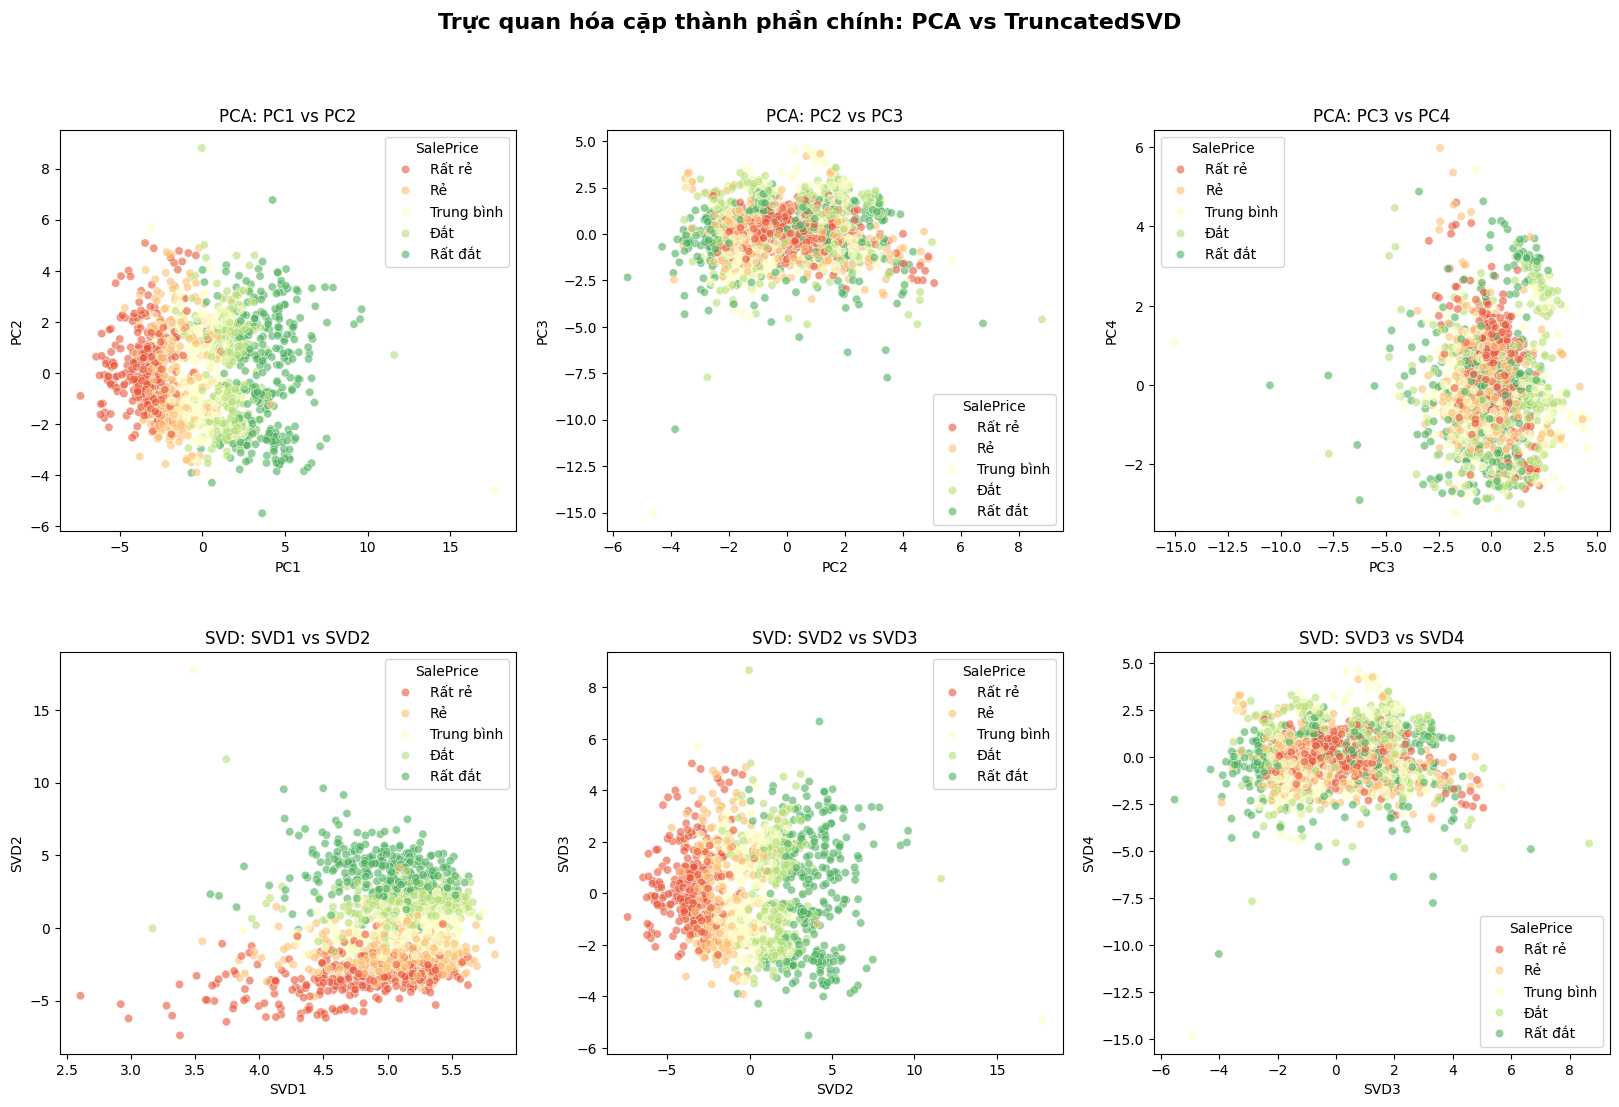

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


y_labels = pd.qcut(Y, q=5, labels=['Rất rẻ', 'Rẻ', 'Trung bình', 'Đắt', 'Rất đắt'])

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
plt.subplots_adjust(hspace=0.3)

# PC1-PC2, PC2-PC3, PC3-PC4 cho PCA
pairs = [(0,1), (1,2), (2,3)]
for i, (p1, p2) in enumerate(pairs):
    sns.scatterplot(x=df_pca.iloc[:, p1], y=df_pca.iloc[:, p2], hue=y_labels, palette='RdYlGn', ax=axes[0, i], alpha=0.6)
    axes[0, i].set_title(f'PCA: {pca_cols[p1]} vs {pca_cols[p2]}')

# Tương tự cho SVD
for i, (p1, p2) in enumerate(pairs):
    sns.scatterplot(x=df_svd.iloc[:, p1], y=df_svd.iloc[:, p2], hue=y_labels, palette='RdYlGn', ax=axes[1, i], alpha=0.6)
    axes[1, i].set_title(f'SVD: {svd_cols[p1]} vs {svd_cols[p2]}')

plt.suptitle('Trực quan hóa cặp thành phần chính: PCA vs TruncatedSVD', fontsize=16, fontweight='bold')
plt.show()

## XÁC ĐỊNH LƯỢNG THÔNG TIN BẢO TỒN (EXPLAINED VARIANCE)

In [ ]:
import pandas as pd
import numpy as np

pca_var = pca.explained_variance_ratio_
svd_var = svd.explained_variance_ratio_

var_summary = pd.DataFrame({
    'Thành phần': [f'Thành phần {i+1}' for i in range(n_comps)],
    'PCA (%)': pca_var * 100,
    'PCA cộng dồn (%)': np.cumsum(pca_var) * 100,
    'SVD (%)': svd_var * 100,
    'SVD cộng dồn (%)': np.cumsum(svd_var) * 100
})

print("\n--- PHƯƠNG SAI GIẢI THÍCH CHI TIẾT ---")
display(var_summary.round(2))

print("=========================================================")
print(f"Tổng phương sai bảo tồn của {n_comps} chiều PCA: {pca_var.sum()*100:.2f}%")
print(f"Tổng phương sai bảo tồn của {n_comps} chiều SVD: {svd_var.sum()*100:.2f}%")
print("---------------------------------------------------------")
print(f"5 thành phần đầu PCA giữ lại: {pca_var[:5].sum()*100:.2f}%")
print(f"5 thành phần đầu SVD giữ lại: {svd_var[:5].sum()*100:.2f}%")
print("=========================================================")


--- PHƯƠNG SAI GIẢI THÍCH CHI TIẾT ---


,Thành phần,PCA (%),PCA cộng dồn (%),SVD (%),SVD cộng dồn (%)
0,Thành phần 1,16.91,16.91,0.37,0.37
1,Thành phần 2,7.46,24.37,16.90,17.26
2,Thành phần 3,5.98,30.34,7.44,24.70
3,Thành phần 4,4.49,34.83,5.94,30.63
4,Thành phần 5,3.60,38.44,4.49,35.12
5,Thành phần 6,3.02,41.45,3.58,38.70
6,Thành phần 7,2.66,44.11,3.01,41.72
7,Thành phần 8,2.56,46.67,2.65,44.37
8,Thành phần 9,2.42,49.08,2.56,46.92
9,Thành phần 10,2.31,51.39,2.42,49.34


Tổng phương sai bảo tồn của 50 chiều PCA: 88.98%
Tổng phương sai bảo tồn của 50 chiều SVD: 88.77%
---------------------------------------------------------
5 thành phần đầu PCA giữ lại: 38.44%
5 thành phần đầu SVD giữ lại: 35.12%


## MỐI QUAN HỆ TƯƠNG QUAN VỚI ĐẦU RA (SALEPRICE)

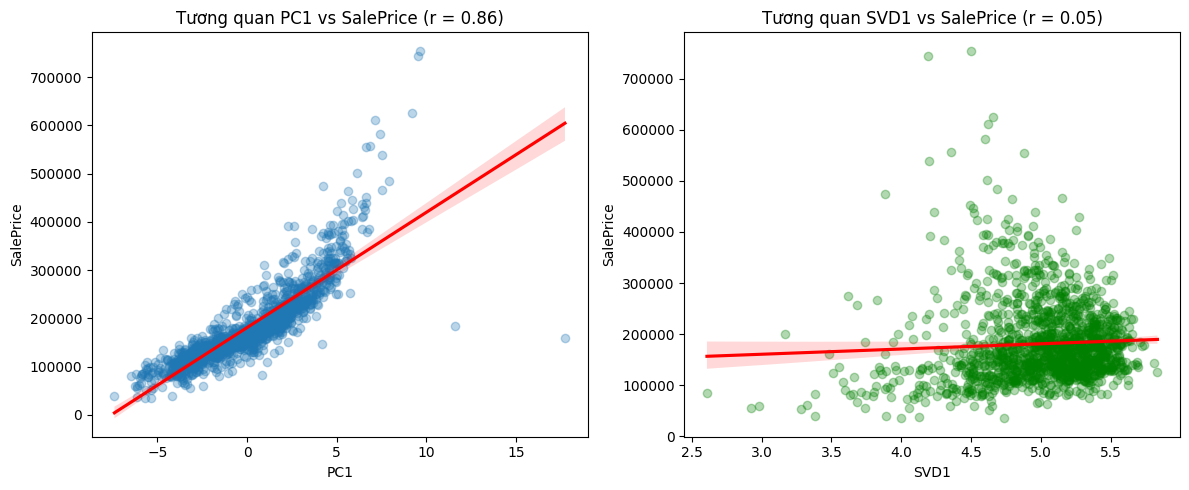

In [ ]:
plt.figure(figsize=(12, 5))

# Tính tương quan của PC1 và SVD1 với SalePrice
pca_corr = np.corrcoef(df_pca['PC1'], Y)[0, 1]
svd_corr = np.corrcoef(df_svd['SVD1'], Y)[0, 1]

plt.subplot(1, 2, 1)
sns.regplot(x=df_pca['PC1'], y=Y, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Tương quan PC1 vs SalePrice (r = {pca_corr:.2f})')

plt.subplot(1, 2, 2)
sns.regplot(x=df_svd['SVD1'], y=Y, scatter_kws={'alpha':0.3, 'color':'green'}, line_kws={'color':'red'})
plt.title(f'Tương quan SVD1 vs SalePrice (r = {svd_corr:.2f})')

plt.tight_layout()
plt.show()

# (III)Phân cụm

## K-means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.stats import kruskal
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


n_components_cluster = 10

X_cluster = df_pca.iloc[:, :n_components_cluster].values

X_vis = df_pca.iloc[:, :2].values

y_price = pd.Series(Y).reset_index(drop=True)

print("Kích thước dữ liệu phân cụm:", X_cluster.shape)
print("Dữ liệu phân cụm KHÔNG chứa trường SalePrice.\n")

Kích thước dữ liệu phân cụm: (1460, 10)
Dữ liệu phân cụm KHÔNG chứa trường SalePrice.



,k,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,28048.4201,0.2268,1.7034,436.4083
1,3,25064.8679,0.2160,1.7225,330.7259
2,4,22603.0286,0.2335,1.5791,297.1912
3,5,20950.6071,0.1850,1.7600,268.9981
4,6,19611.5220,0.1848,1.7257,249.5903
5,7,18425.3528,0.1957,1.6323,236.8195
6,8,17462.7176,0.1943,1.5979,225.4651
7,9,16532.8414,0.1948,1.5441,218.4357
8,10,15887.6481,0.1919,1.5195,208.4535



=> Số cụm K-Means được chọn theo Silhouette Score: k = 4


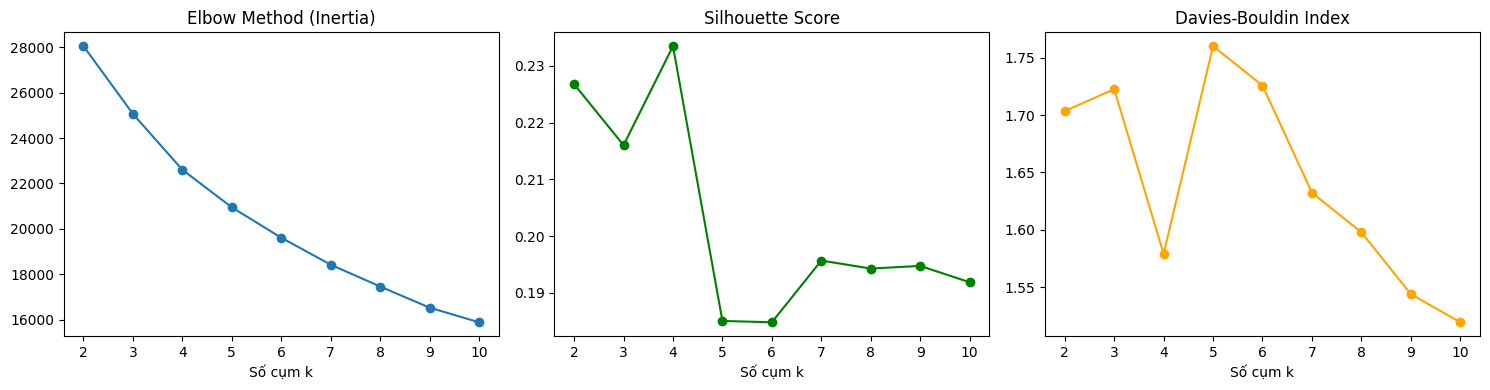

In [ ]:
k_values = range(2, 11)
kmeans_results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_cluster)

    kmeans_results.append({
        "k": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X_cluster, labels),
        "Davies-Bouldin": davies_bouldin_score(X_cluster, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_cluster, labels)
    })

kmeans_eval = pd.DataFrame(kmeans_results)
display(kmeans_eval.round(4))

# Chọn k theo Silhouette lớn nhất
best_k = int(kmeans_eval.loc[kmeans_eval["Silhouette"].idxmax(), "k"])
print(f"\n=> Số cụm K-Means được chọn theo Silhouette Score: k = {best_k}")

# Biểu đồ Elbow và Silhouette
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(kmeans_eval["k"], kmeans_eval["Inertia"], marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("Số cụm k")

plt.subplot(1, 3, 2)
plt.plot(kmeans_eval["k"], kmeans_eval["Silhouette"], marker='o', color='green')
plt.title("Silhouette Score")
plt.xlabel("Số cụm k")

plt.subplot(1, 3, 3)
plt.plot(kmeans_eval["k"], kmeans_eval["Davies-Bouldin"], marker='o', color='orange')
plt.title("Davies-Bouldin Index")
plt.xlabel("Số cụm k")
plt.tight_layout()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels_kmeans = kmeans.fit_predict(X_cluster)

print("Số lượng mẫu trong từng cụm K-Means:")
display(pd.Series(labels_kmeans, name="Cluster").value_counts().sort_index().to_frame("Số mẫu"))

print("\nĐộ đo chất lượng cụm K-Means:")
print(f"Silhouette Score      : {silhouette_score(X_cluster, labels_kmeans):.4f}")
print(f"Davies-Bouldin Index  : {davies_bouldin_score(X_cluster, labels_kmeans):.4f}")
print(f"Calinski-Harabasz     : {calinski_harabasz_score(X_cluster, labels_kmeans):.4f}")

Số lượng mẫu trong từng cụm K-Means:


,Số mẫu
Cluster,
0,342
1,81
2,668
3,369



Độ đo chất lượng cụm K-Means:
Silhouette Score      : 0.2335
Davies-Bouldin Index  : 1.5791
Calinski-Harabasz     : 297.1912


## GMM

In [ ]:
from sklearn.mixture import GaussianMixture

gmm_results = []

for k in k_values:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=5
    )

    labels = gmm.fit_predict(X_cluster)

    gmm_results.append({
        "k": k,
        "BIC": gmm.bic(X_cluster),
        "AIC": gmm.aic(X_cluster),
        "Silhouette": silhouette_score(X_cluster, labels),
        "Davies-Bouldin": davies_bouldin_score(X_cluster, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_cluster, labels)
    })

gmm_eval = pd.DataFrame(gmm_results)
display(gmm_eval.round(4))

# Chọn số cụm
best_gmm_k_bic = int(gmm_eval.loc[gmm_eval["BIC"].idxmin(), "k"])
best_gmm_k_sil = int(gmm_eval.loc[gmm_eval["Silhouette"].idxmax(), "k"])

print(f"Số cụm GMM theo BIC nhỏ nhất: k = {best_gmm_k_bic}")
print(f"Số cụm GMM theo Silhouette lớn nhất: k = {best_gmm_k_sil}")

,k,BIC,AIC,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,48425.2192,47732.7280,0.1663,2.0790,290.2222
1,3,45784.1241,44742.7443,0.1321,2.4180,225.8793
2,4,45416.8780,44026.6096,0.1345,2.9799,167.0104
3,5,44324.0834,42584.9263,0.1365,2.2972,169.6340
4,6,44239.2426,42151.1969,0.1418,2.1013,186.0332
5,7,44080.9568,41644.0224,0.1299,2.4058,167.1960
6,8,44144.1241,41358.3010,0.1162,1.9889,151.4277
7,9,44014.3967,40879.6851,0.1388,1.8690,163.7462
8,10,44307.5074,40823.9070,0.1259,2.0605,154.0813


Số cụm GMM theo BIC nhỏ nhất: k = 9
Số cụm GMM theo Silhouette lớn nhất: k = 2


In [ ]:
best_gmm_k = best_gmm_k_bic

gmm_final = GaussianMixture(
    n_components=best_gmm_k,
    covariance_type='full',
    random_state=42,
    n_init=5
)

labels_gmm = gmm_final.fit_predict(X_cluster)
probs_gmm = gmm_final.predict_proba(X_cluster)

print("Số lượng mẫu trong từng cụm GMM:")
display(pd.Series(labels_gmm, name="Cluster").value_counts().sort_index().to_frame("Số mẫu"))

print("\nĐộ đo chất lượng cụm GMM:")
print(f"Silhouette Score      : {silhouette_score(X_cluster, labels_gmm):.4f}")
print(f"Davies-Bouldin Index  : {davies_bouldin_score(X_cluster, labels_gmm):.4f}")
print(f"Calinski-Harabasz     : {calinski_harabasz_score(X_cluster, labels_gmm):.4f}")

Số lượng mẫu trong từng cụm GMM:


,Số mẫu
Cluster,
0,234
1,317
2,139
3,81
4,238
5,98
6,190
7,103
8,60



Độ đo chất lượng cụm GMM:
Silhouette Score      : 0.1388
Davies-Bouldin Index  : 1.8690
Calinski-Harabasz     : 163.7462


## DBScan

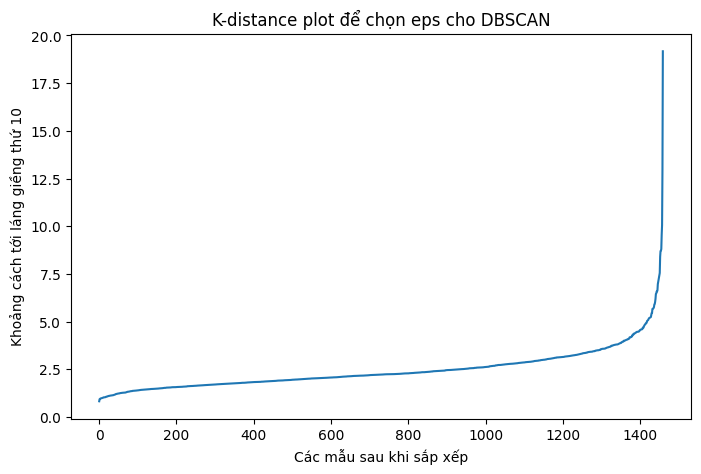

,eps,min_samples,Số cụm,Tỉ lệ nhiễu,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2.6784,10,2,0.1610,0.2918,1.0161,111.7885
1,2.8492,10,3,0.1233,0.1781,1.0692,69.2061
2,3.0495,10,2,0.0938,0.2879,1.0580,125.2885
3,3.2753,10,2,0.0664,0.2862,1.0833,132.9352
4,3.6229,10,2,0.0425,0.2831,1.1051,135.7492
5,3.8057,10,2,0.0336,0.2856,1.1359,141.6133
6,4.3766,10,2,0.0185,0.2920,1.1867,152.3460
7,4.9156,10,1,0.0123,NaN,NaN,NaN
8,5.4271,10,1,0.0089,NaN,NaN,NaN
9,6.6025,10,1,0.0034,NaN,NaN,NaN


eps được chọn cho DBSCAN: 4.3766


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Chọn eps
min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_cluster)
distances, indices = neighbors_fit.kneighbors(X_cluster)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Các mẫu sau khi sắp xếp")
plt.ylabel(f"Khoảng cách tới láng giềng thứ {min_samples}")
plt.title("K-distance plot để chọn eps cho DBSCAN")
plt.show()

eps_candidates = np.percentile(k_distances, [70, 75, 80, 85, 90, 92, 95, 97, 98, 99])

dbscan_results = []

for eps in eps_candidates:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_cluster)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)

    mask = labels != -1
    valid_labels = labels[mask]

    if n_clusters >= 2 and len(set(valid_labels)) >= 2:
        sil = silhouette_score(X_cluster[mask], valid_labels)
        dbi = davies_bouldin_score(X_cluster[mask], valid_labels)
        ch = calinski_harabasz_score(X_cluster[mask], valid_labels)
    else:
        sil, dbi, ch = np.nan, np.nan, np.nan

    dbscan_results.append({
        "eps": eps,
        "min_samples": min_samples,
        "Số cụm": n_clusters,
        "Tỉ lệ nhiễu": noise_ratio,
        "Silhouette": sil,
        "Davies-Bouldin": dbi,
        "Calinski-Harabasz": ch
    })

dbscan_eval = pd.DataFrame(dbscan_results)
display(dbscan_eval.round(4))


valid_dbscan = dbscan_eval.dropna(subset=["Silhouette"]).copy()

valid_dbscan = valid_dbscan[
    (valid_dbscan["Số cụm"] >= 2) &
    (valid_dbscan["Tỉ lệ nhiễu"] < 0.5)
]

if len(valid_dbscan) > 0:
    best_dbscan_eps = float(valid_dbscan.loc[valid_dbscan["Silhouette"].idxmax(), "eps"])
else:
    best_dbscan_eps = float(eps_candidates[4])

print(f"eps được chọn cho DBSCAN: {best_dbscan_eps:.4f}")

In [ ]:
dbscan = DBSCAN(eps=best_dbscan_eps, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X_cluster)

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
noise_ratio_dbscan = np.mean(labels_dbscan == -1)

print("Số cụm DBSCAN:", n_clusters_dbscan)
print(f"Tỉ lệ nhiễu: {noise_ratio_dbscan:.4f}")

print("\nSố lượng mẫu trong từng cụm DBSCAN:")
display(pd.Series(labels_dbscan, name="Cluster").value_counts().sort_index().to_frame("Số mẫu"))

mask = labels_dbscan != -1

if n_clusters_dbscan >= 2 and len(set(labels_dbscan[mask])) >= 2:
    print("\nĐộ đo chất lượng cụm DBSCAN, không tính nhiễu:")
    print(f"Silhouette Score      : {silhouette_score(X_cluster[mask], labels_dbscan[mask]):.4f}")
    print(f"Davies-Bouldin Index  : {davies_bouldin_score(X_cluster[mask], labels_dbscan[mask]):.4f}")
    print(f"Calinski-Harabasz     : {calinski_harabasz_score(X_cluster[mask], labels_dbscan[mask]):.4f}")
else:
    print("\nDBSCAN không tạo đủ số cụm hợp lệ để tính các chỉ số đánh giá.")

Số cụm DBSCAN: 2
Tỉ lệ nhiễu: 0.0185

Số lượng mẫu trong từng cụm DBSCAN:


,Số mẫu
Cluster,
-1,27
0,1360
1,73



Độ đo chất lượng cụm DBSCAN, không tính nhiễu:
Silhouette Score      : 0.2920
Davies-Bouldin Index  : 1.1867
Calinski-Harabasz     : 152.3460


## Đánh giá quan hệ giữa cụm và đầu ra

In [ ]:
from scipy.stats import kruskal, f_oneway
import numpy as np
import pandas as pd

def evaluate_price_by_cluster(labels, method_name, ignore_noise=True):
    df = pd.DataFrame({
        "Cluster": labels,
        "SalePrice": y_price
    })

    if ignore_noise:
        df_eval = df[df["Cluster"] != -1].copy()
    else:
        df_eval = df.copy()

    summary = df_eval.groupby("Cluster")["SalePrice"].agg(
        So_mau="count",
        Gia_TB="mean",
        Trung_vi="median",
        Do_lech_chuan="std",
        Gia_min="min",
        Gia_max="max"
    )

    summary["He_so_bien_thien_CV"] = summary["Do_lech_chuan"] / summary["Gia_TB"]

    groups = [
        g["SalePrice"].values
        for _, g in df_eval.groupby("Cluster")
        if len(g) > 1
    ]

    if len(groups) >= 2:
        anova_stat, anova_p = f_oneway(*groups)
        kruskal_stat, kruskal_p = kruskal(*groups)

        overall_mean = df_eval["SalePrice"].mean()
        ss_between = sum(len(g) * (np.mean(g) - overall_mean) ** 2 for g in groups)
        ss_total = sum((df_eval["SalePrice"] - overall_mean) ** 2)
        eta_squared = ss_between / ss_total
    else:
        anova_stat, anova_p = np.nan, np.nan
        kruskal_stat, kruskal_p = np.nan, np.nan
        eta_squared = np.nan

    print(f"\n===== {method_name} =====")
    print("Thống kê SalePrice theo cụm:")
    display(summary.round(2))

    print("\nĐánh giá định lượng quan hệ giữa cụm và SalePrice:")
    print(f"ANOVA F-statistic   : {anova_stat:.4f}")
    print(f"ANOVA p-value       : {anova_p:.6f}")
    print(f"Kruskal statistic   : {kruskal_stat:.4f}")
    print(f"Kruskal p-value     : {kruskal_p:.6f}")
    print(f"Eta squared         : {eta_squared:.4f}")

    if not np.isnan(anova_p):
        if anova_p < 0.05:
            print("Nhận xét: p-value < 0.05, giá nhà giữa các cụm có sự khác biệt có ý nghĩa thống kê.")
        else:
            print("Nhận xét: p-value >= 0.05, chưa đủ bằng chứng để kết luận giá nhà khác biệt rõ giữa các cụm.")

    return summary

summary_kmeans = evaluate_price_by_cluster(labels_kmeans, "K-Means")
summary_gmm = evaluate_price_by_cluster(labels_gmm, "GMM")
summary_dbscan = evaluate_price_by_cluster(labels_dbscan, "DBSCAN", ignore_noise=True)


===== K-Means =====
Thống kê SalePrice theo cụm:


,So_mau,Gia_TB,Trung_vi,Do_lech_chuan,Gia_min,Gia_max,He_so_bien_thien_CV
Cluster,,,,,,,
0,342,235606.42,215000.0,74657.38,82500,611657,0.32
1,81,103317.28,100000.0,32815.02,34900,200500,0.32
2,668,133126.78,133950.0,28809.02,35311,250000,0.22
3,369,233794.49,212000.0,84046.78,107500,755000,0.36



Đánh giá định lượng quan hệ giữa cụm và SalePrice:
ANOVA F-statistic   : 384.1256
ANOVA p-value       : 0.000000
Kruskal statistic   : 936.9620
Kruskal p-value     : 0.000000
Eta squared         : 0.4418
Nhận xét: p-value < 0.05, giá nhà giữa các cụm có sự khác biệt có ý nghĩa thống kê.

===== GMM =====
Thống kê SalePrice theo cụm:


,So_mau,Gia_TB,Trung_vi,Do_lech_chuan,Gia_min,Gia_max,He_so_bien_thien_CV
Cluster,,,,,,,
0,234,229825.88,213750.0,68558.25,130000,556581,0.30
1,317,123163.89,126000.0,25342.56,35311,237500,0.21
2,139,243657.58,220000.0,86718.73,126000,611657,0.36
3,81,103317.28,100000.0,32815.02,34900,200500,0.32
4,238,169801.04,157250.0,51922.72,80000,394617,0.31
5,98,222058.58,209200.0,54752.34,140000,415298,0.25
6,190,180743.39,172250.0,60352.80,75000,475000,0.33
7,103,138926.07,135000.0,38672.32,62383,265979,0.28
8,60,304343.60,272485.0,134808.98,129000,755000,0.44



Đánh giá định lượng quan hệ giữa cụm và SalePrice:
ANOVA F-statistic   : 135.8321
ANOVA p-value       : 0.000000
Kruskal statistic   : 833.2328
Kruskal p-value     : 0.000000
Eta squared         : 0.4282
Nhận xét: p-value < 0.05, giá nhà giữa các cụm có sự khác biệt có ý nghĩa thống kê.

===== DBSCAN =====
Thống kê SalePrice theo cụm:


,So_mau,Gia_TB,Trung_vi,Do_lech_chuan,Gia_min,Gia_max,He_so_bien_thien_CV
Cluster,,,,,,,
0,1360,183844.96,166500.0,75526.80,35311,625000,0.41
1,73,98769.86,97000.0,28869.49,34900,179000,0.29



Đánh giá định lượng quan hệ giữa cụm và SalePrice:
ANOVA F-statistic   : 91.8522
ANOVA p-value       : 0.000000
Kruskal statistic   : 133.9491
Kruskal p-value     : 0.000000
Eta squared         : 0.0603
Nhận xét: p-value < 0.05, giá nhà giữa các cụm có sự khác biệt có ý nghĩa thống kê.


In [ ]:
comparison = pd.DataFrame({
    "Phương pháp": ["K-Means", "GMM", "DBSCAN"],
    "Số cụm": [
        len(set(labels_kmeans)),
        len(set(labels_gmm)),
        n_clusters_dbscan
    ],
    "Silhouette": [
        silhouette_score(X_cluster, labels_kmeans),
        silhouette_score(X_cluster, labels_gmm),
        silhouette_score(X_cluster[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])
    ],
    "Davies-Bouldin": [
        davies_bouldin_score(X_cluster, labels_kmeans),
        davies_bouldin_score(X_cluster, labels_gmm),
        davies_bouldin_score(X_cluster[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])
    ],
    "Calinski-Harabasz": [
        calinski_harabasz_score(X_cluster, labels_kmeans),
        calinski_harabasz_score(X_cluster, labels_gmm),
        calinski_harabasz_score(X_cluster[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])
    ]
})

display(comparison.round(4))

,Phương pháp,Số cụm,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,4,0.2335,1.5791,297.1912
1,GMM,9,0.1388,1.8690,163.7462
2,DBSCAN,2,0.2920,1.1867,152.3460


## Trực quan hóa cụm trên không gian PCA 2 chiều

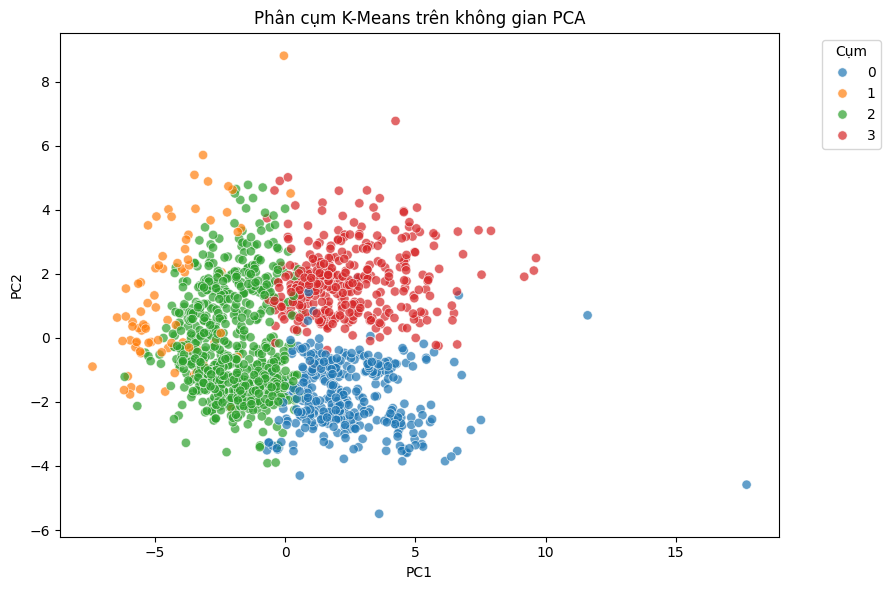

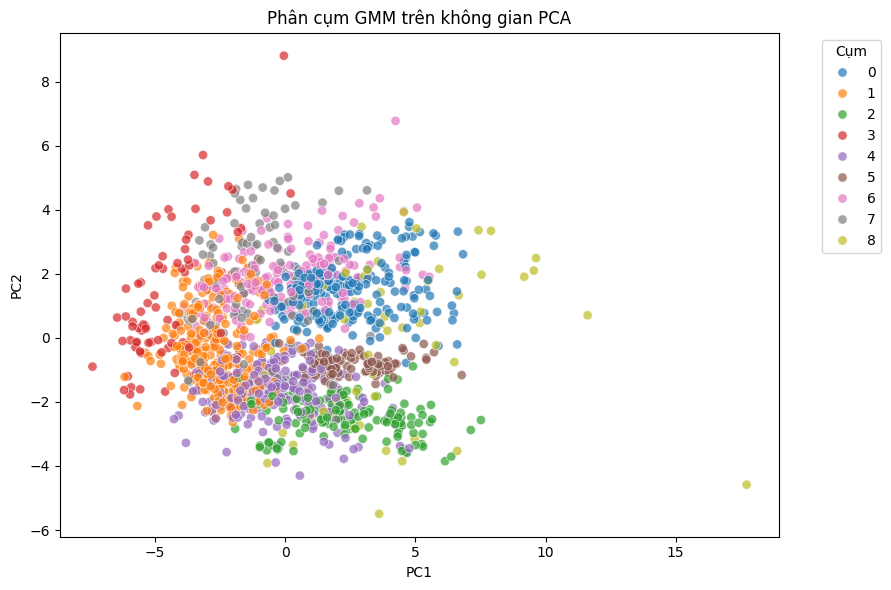

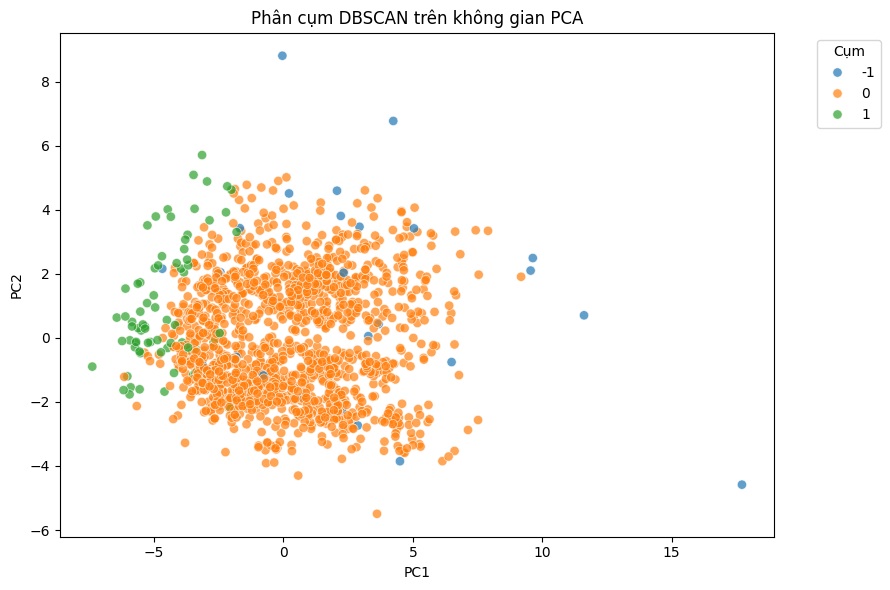

In [ ]:
def plot_clusters(labels, title):
    plot_df = pd.DataFrame({
        "PC1": X_vis[:, 0],
        "PC2": X_vis[:, 1],
        "Cluster": labels,
        "SalePrice": y_price
    })

    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=plot_df,
        x="PC1", y="PC2",
        hue="Cluster",
        palette="tab10",
        alpha=0.7,
        s=45
    )
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Cụm", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_clusters(labels_kmeans, "Phân cụm K-Means trên không gian PCA")
plot_clusters(labels_gmm, "Phân cụm GMM trên không gian PCA")
plot_clusters(labels_dbscan, "Phân cụm DBSCAN trên không gian PCA")

## Trực quan hóa SalePrice theo cụm

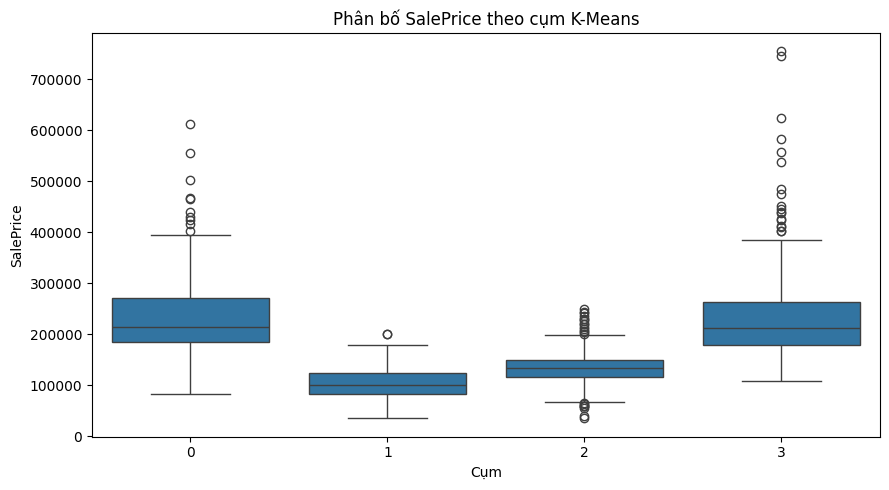

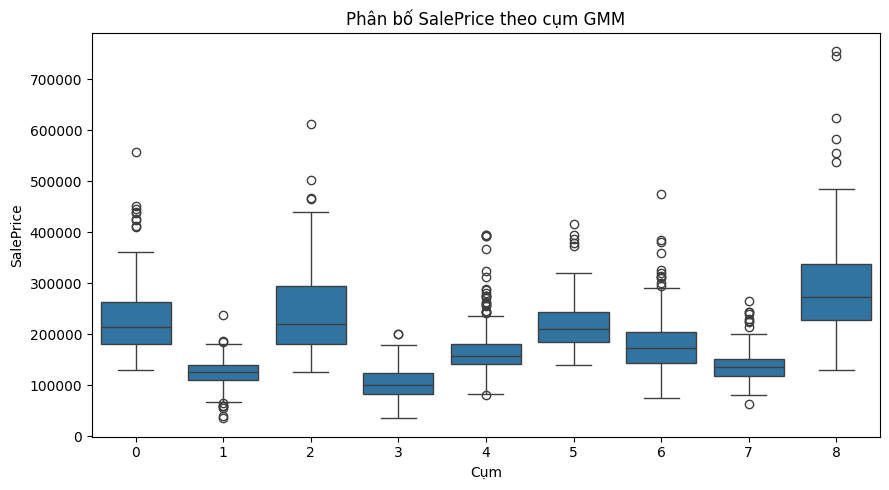

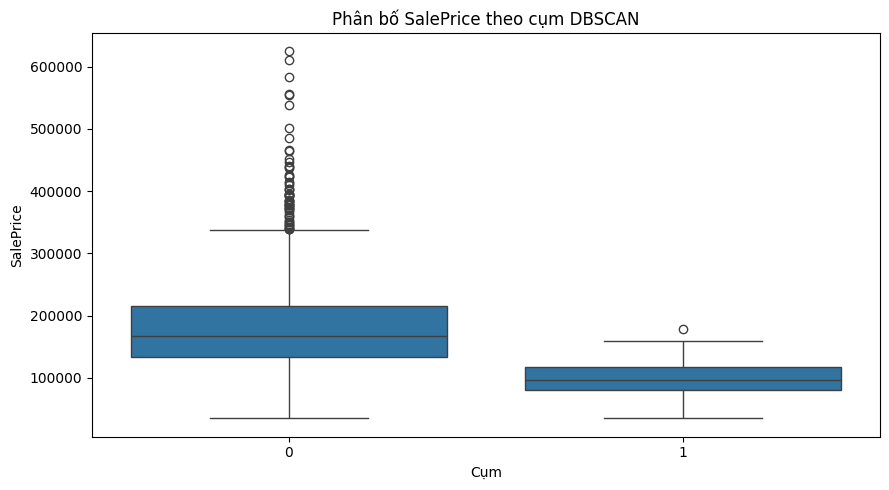

In [ ]:
def boxplot_price_by_cluster(labels, title, ignore_noise=True):
    df = pd.DataFrame({
        "Cluster": labels,
        "SalePrice": y_price
    })
    if ignore_noise:
        df = df[df["Cluster"] != -1]

    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x="Cluster", y="SalePrice")
    plt.title(title)
    plt.xlabel("Cụm")
    plt.ylabel("SalePrice")
    plt.tight_layout()
    plt.show()

boxplot_price_by_cluster(labels_kmeans, "Phân bố SalePrice theo cụm K-Means")
boxplot_price_by_cluster(labels_gmm, "Phân bố SalePrice theo cụm GMM")
boxplot_price_by_cluster(labels_dbscan, "Phân bố SalePrice theo cụm DBSCAN", ignore_noise=True)

# (IV)Phân tích hồi quy

##1.K-NN

### (a)

In [ ]:
def distances(array,value) :
  array = np.array(array)
  return np.linalg.norm(array - value, axis=1)

In [ ]:
def find_nearest_index(array,value,k) :
  array_D = distances(array,value)
  return np.argsort(array_D)[:k]

In [ ]:
def KNN(X_train,y_train,X_test,k):
  X_train = np.array(X_train)
  X_test = np.array(X_test)
  y_pred = []
  y_train = np.array(y_train)
  for i in range(len(X_test)):
    indexes = find_nearest_index(X_train,X_test[i],k)
    y_pred.append(np.mean(y_train[indexes]))
  return np.array(y_pred)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

def train_test_KNN(X,Y,test_size):
  X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, random_state=42)
  return X_train, X_test, y_train, y_test


test_sizes = [0.2, 0.3, 0.4]
ratio_names = {
    0.2: "4:1",
    0.3: "7:3",
    0.4: "6:4"
}
K = 5


### Với dữ liệu gốc

In [ ]:
print("--- KẾT QUẢ TRÊN DỮ LIỆU GỐC (X_scaled) ---")

for size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_KNN(X_scaled, Y, size)

    y_train_pred = KNN(X_train, y_train, X_train, K)
    y_test_pred = KNN(X_train, y_train, X_test, K)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"Tỉ lệ {ratio_names[size]} | Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")





--- KẾT QUẢ TRÊN DỮ LIỆU GỐC (X_scaled) ---
Tỉ lệ 4:1 | Train R2: 0.8299 | Test R2: 0.8045
Tỉ lệ 7:3 | Train R2: 0.8234 | Test R2: 0.8001
Tỉ lệ 6:4 | Train R2: 0.8312 | Test R2: 0.7778


### Với dữ liệu giảm chiều

In [ ]:
print("\n--- KẾT QUẢ TRÊN DỮ LIỆU GIẢM CHIỀU (X_pca) ---")

for size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_KNN(X_pca, Y, size)

    y_train_pred = KNN(X_train, y_train, X_train, K)
    y_test_pred = KNN(X_train, y_train, X_test, K)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"Tỉ lệ {ratio_names[size]} | Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")


--- KẾT QUẢ TRÊN DỮ LIỆU GIẢM CHIỀU (X_pca) ---
Tỉ lệ 4:1 | Train R2: 0.8295 | Test R2: 0.8103
Tỉ lệ 7:3 | Train R2: 0.8248 | Test R2: 0.8042
Tỉ lệ 6:4 | Train R2: 0.8310 | Test R2: 0.7777


In [ ]:
K = 10

print("--- KẾT QUẢ KNN VỚI K = 10 TRÊN DỮ LIỆU GỐC (X_scaled) ---")

for size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_KNN(X_scaled, Y, size)

    y_train_pred = KNN(X_train, y_train, X_train, K)
    y_test_pred = KNN(X_train, y_train, X_test, K)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(
        f"Tỉ lệ {ratio_names[size]} | "
        f"Train R2: {train_r2:.4f} | "
        f"Test R2: {test_r2:.4f} | "
        f"Gap: {train_r2 - test_r2:.4f}"
    )


print("\n--- KẾT QUẢ KNN VỚI K = 10 TRÊN DỮ LIỆU GIẢM CHIỀU (X_pca) ---")

for size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_KNN(X_pca, Y, size)

    y_train_pred = KNN(X_train, y_train, X_train, K)
    y_test_pred = KNN(X_train, y_train, X_test, K)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(
        f"Tỉ lệ {ratio_names[size]} | "
        f"Train R2: {train_r2:.4f} | "
        f"Test R2: {test_r2:.4f} | "
        f"Gap: {train_r2 - test_r2:.4f}"
    )

--- KẾT QUẢ KNN VỚI K = 10 TRÊN DỮ LIỆU GỐC (X_scaled) ---
Tỉ lệ 4:1 | Train R2: 0.8135 | Test R2: 0.8043 | Gap: 0.0092
Tỉ lệ 7:3 | Train R2: 0.8034 | Test R2: 0.8027 | Gap: 0.0007
Tỉ lệ 6:4 | Train R2: 0.8071 | Test R2: 0.7728 | Gap: 0.0344

--- KẾT QUẢ KNN VỚI K = 10 TRÊN DỮ LIỆU GIẢM CHIỀU (X_pca) ---
Tỉ lệ 4:1 | Train R2: 0.8165 | Test R2: 0.8034 | Gap: 0.0131
Tỉ lệ 7:3 | Train R2: 0.8079 | Test R2: 0.8050 | Gap: 0.0029
Tỉ lệ 6:4 | Train R2: 0.8075 | Test R2: 0.7765 | Gap: 0.0310


### (b)

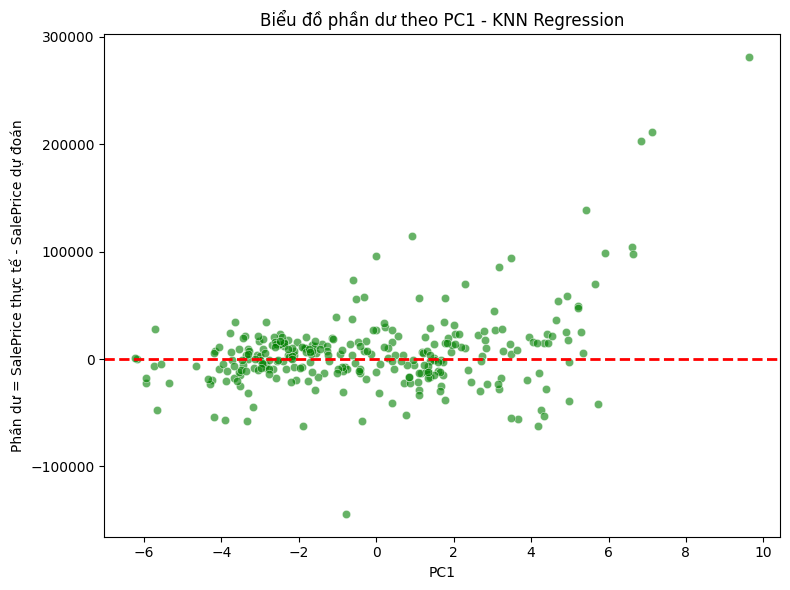

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

size = 0.2
K = 5

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_KNN(X_pca, Y, size)

y_pred_pca = KNN(X_train_pca, y_train_pca, X_test_pca, K)

# Phần dư
residuals_pca = y_test_pca - y_pred_pca

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_test_pca[:, 0],
    y=residuals_pca,
    alpha=0.6,
    color='green'
)

plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel('PC1')
plt.ylabel('Phần dư = SalePrice thực tế - SalePrice dự đoán')
plt.title('Biểu đồ phần dư theo PC1 - KNN Regression')

plt.tight_layout()
plt.show()

## 2.Hồi quy tuyến tính


### (a)

In [ ]:
import numpy as np
import pandas as pd

def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def train_linear(X, y):
    X_b = add_bias(X)
    beta = np.linalg.pinv(X_b) @ y
    return beta

def predict_linear(X, beta):
    X_b = add_bias(X)
    return X_b @ beta

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r2_score_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

def split_data(X, y, test_ratio, random_state=42):
    np.random.seed(random_state)

    n = len(X)
    idx = np.random.permutation(n)
    k = int(n * test_ratio)

    test_idx = idx[:k]
    train_idx = idx[k:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

### Với dữ liệu gốc

In [ ]:
X_raw = x_all.values
y_np = Y.values

print("--- KẾT QUẢ LINEAR REGRESSION TRÊN DỮ LIỆU GỐC (X_scaled) ---")

linear_raw_results = []

for size in test_sizes:
    X_train, X_test, y_train, y_test = split_data(X_raw, y_np, size)

    beta = train_linear(X_train, y_train)

    y_train_pred = predict_linear(X_train, beta)
    y_test_pred = predict_linear(X_test, beta)

    train_r2 = r2_score_manual(y_train, y_train_pred)
    test_r2 = r2_score_manual(y_test, y_test_pred)

    train_rmse = rmse(y_train, y_train_pred)
    test_rmse = rmse(y_test, y_test_pred)

    gap = train_r2 - test_r2

    linear_raw_results.append({
        "Dữ liệu": "X_scaled",
        "Tỉ lệ train:test": ratio_names[size],
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Gap": gap,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

    print(
        f"Tỉ lệ {ratio_names[size]} | "
        f"Train R2: {train_r2:.4f} | "
        f"Test R2: {test_r2:.4f} | "
        f"Gap: {gap:.4f} | "
        f"Test RMSE: {test_rmse:.2f}"
    )

linear_raw_results = pd.DataFrame(linear_raw_results)
display(linear_raw_results.round(4))

--- KẾT QUẢ LINEAR REGRESSION TRÊN DỮ LIỆU GỐC (X_scaled) ---
Tỉ lệ 4:1 | Train R2: 0.9409 | Test R2: -0.0881 | Gap: 1.0290 | Test RMSE: 91357.37
Tỉ lệ 7:3 | Train R2: 0.9418 | Test R2: -0.1587 | Gap: 1.1004 | Test RMSE: 89918.73
Tỉ lệ 6:4 | Train R2: 0.9380 | Test R2: 0.8162 | Gap: 0.1217 | Test RMSE: 36494.51


,Dữ liệu,Tỉ lệ train:test,Train R2,Test R2,Gap,Train RMSE,Test RMSE
0,X_scaled,4:1,0.9409,-0.0881,1.0290,18773.3207,91357.3656
1,X_scaled,7:3,0.9418,-0.1587,1.1004,18721.4747,89918.7323
2,X_scaled,6:4,0.9380,0.8162,0.1217,18767.7250,36494.5098


### Với dữ liệu đã giảm chiều

In [ ]:
X_pca_np = X_pca
y_np = Y.values

print("\n--- KẾT QUẢ LINEAR REGRESSION TRÊN DỮ LIỆU GIẢM CHIỀU (X_pca) ---")

linear_pca_results = []

for size in test_sizes:
    X_train, X_test, y_train, y_test = split_data(X_pca_np, y_np, size)

    beta = train_linear(X_train, y_train)

    y_train_pred = predict_linear(X_train, beta)
    y_test_pred = predict_linear(X_test, beta)

    train_r2 = r2_score_manual(y_train, y_train_pred)
    test_r2 = r2_score_manual(y_test, y_test_pred)

    train_rmse = rmse(y_train, y_train_pred)
    test_rmse = rmse(y_test, y_test_pred)

    gap = train_r2 - test_r2

    linear_pca_results.append({
        "Dữ liệu": "X_pca",
        "Tỉ lệ train:test": ratio_names[size],
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Gap": gap,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

    print(
        f"Tỉ lệ {ratio_names[size]} | "
        f"Train R2: {train_r2:.4f} | "
        f"Test R2: {test_r2:.4f} | "
        f"Gap: {gap:.4f} | "
        f"Test RMSE: {test_rmse:.2f}"
    )

linear_pca_results = pd.DataFrame(linear_pca_results)
display(linear_pca_results.round(4))


--- KẾT QUẢ LINEAR REGRESSION TRÊN DỮ LIỆU GIẢM CHIỀU (X_pca) ---
Tỉ lệ 4:1 | Train R2: 0.8266 | Test R2: 0.8423 | Gap: -0.0157 | Test RMSE: 34784.41
Tỉ lệ 7:3 | Train R2: 0.8184 | Test R2: 0.8466 | Gap: -0.0282 | Test RMSE: 32717.55
Tỉ lệ 6:4 | Train R2: 0.8221 | Test R2: 0.8108 | Gap: 0.0114 | Test RMSE: 37031.50


,Dữ liệu,Tỉ lệ train:test,Train R2,Test R2,Gap,Train RMSE,Test RMSE
0,X_pca,4:1,0.8266,0.8423,-0.0157,32164.1264,34784.4121
1,X_pca,7:3,0.8184,0.8466,-0.0282,33056.4177,32717.5462
2,X_pca,6:4,0.8221,0.8108,0.0114,31775.9954,37031.4983


### Hiệu chỉnh Ridge

In [ ]:
def train_ridge(X, y, lam=10):
    X_b = add_bias(X)

    I = np.eye(X_b.shape[1])
    I[0, 0] = 0

    beta = np.linalg.pinv(X_b.T @ X_b + lam * I) @ X_b.T @ y
    return beta

In [ ]:
def evaluate_ridge_regression(X_data, y_data, data_name, lam=10):
    print(f"\n--- KẾT QUẢ RIDGE REGRESSION TRÊN {data_name} | lambda = {lam} ---")

    results = []

    for size in test_sizes:
        X_train, X_test, y_train, y_test = split_data(X_data, y_data, size)

        beta = train_ridge(X_train, y_train, lam=lam)

        y_train_pred = predict_linear(X_train, beta)
        y_test_pred = predict_linear(X_test, beta)

        train_r2 = r2_score_manual(y_train, y_train_pred)
        test_r2 = r2_score_manual(y_test, y_test_pred)

        train_rmse = rmse(y_train, y_train_pred)
        test_rmse = rmse(y_test, y_test_pred)

        gap = train_r2 - test_r2

        results.append({
            "Mô hình": "Ridge Regression",
            "Dữ liệu": data_name,
            "Lambda": lam,
            "Tỉ lệ train:test": ratio_names[size],
            "Train R2": train_r2,
            "Test R2": test_r2,
            "Gap": gap,
            "Train RMSE": train_rmse,
            "Test RMSE": test_rmse
        })

        print(
            f"Tỉ lệ {ratio_names[size]} | "
            f"Train R2: {train_r2:.4f} | "
            f"Test R2: {test_r2:.4f} | "
            f"Gap: {gap:.4f} | "
            f"Test RMSE: {test_rmse:.2f}"
        )

    return pd.DataFrame(results)

In [ ]:
X_raw = x_all.values
X_pca_np = X_pca
y_np = Y.values

ridge_raw_results = evaluate_ridge_regression(
    X_raw,
    y_np,
    "DỮ LIỆU GỐC X_scaled",
    lam=10
)

ridge_pca_results = evaluate_ridge_regression(
    X_pca_np,
    y_np,
    "DỮ LIỆU GIẢM CHIỀU X_pca",
    lam=10
)

ridge_results = pd.concat(
    [ridge_raw_results, ridge_pca_results],
    ignore_index=True
)

display(ridge_results.round(4))


--- KẾT QUẢ RIDGE REGRESSION TRÊN DỮ LIỆU GỐC X_scaled | lambda = 10 ---
Tỉ lệ 4:1 | Train R2: 0.8968 | Test R2: 0.8764 | Gap: 0.0204 | Test RMSE: 30787.42
Tỉ lệ 7:3 | Train R2: 0.8951 | Test R2: 0.8775 | Gap: 0.0176 | Test RMSE: 29238.77
Tỉ lệ 6:4 | Train R2: 0.8975 | Test R2: 0.8520 | Gap: 0.0455 | Test RMSE: 32750.25

--- KẾT QUẢ RIDGE REGRESSION TRÊN DỮ LIỆU GIẢM CHIỀU X_pca | lambda = 10 ---
Tỉ lệ 4:1 | Train R2: 0.8265 | Test R2: 0.8421 | Gap: -0.0156 | Test RMSE: 34801.75
Tỉ lệ 7:3 | Train R2: 0.8184 | Test R2: 0.8467 | Gap: -0.0283 | Test RMSE: 32704.14
Tỉ lệ 6:4 | Train R2: 0.8221 | Test R2: 0.8109 | Gap: 0.0111 | Test RMSE: 37016.03


,Mô hình,Dữ liệu,Lambda,Tỉ lệ train:test,Train R2,Test R2,Gap,Train RMSE,Test RMSE
0,Ridge Regression,DỮ LIỆU GỐC X_scaled,10,4:1,0.8968,0.8764,0.0204,24804.6810,30787.4196
1,Ridge Regression,DỮ LIỆU GỐC X_scaled,10,7:3,0.8951,0.8775,0.0176,25124.5705,29238.7657
2,Ridge Regression,DỮ LIỆU GỐC X_scaled,10,6:4,0.8975,0.8520,0.0455,24124.0416,32750.2470
3,Ridge Regression,DỮ LIỆU GIẢM CHIỀU X_pca,10,4:1,0.8265,0.8421,-0.0156,32167.8377,34801.7528
4,Ridge Regression,DỮ LIỆU GIẢM CHIỀU X_pca,10,7:3,0.8184,0.8467,-0.0283,33061.3910,32704.1387
5,Ridge Regression,DỮ LIỆU GIẢM CHIỀU X_pca,10,6:4,0.8221,0.8109,0.0111,31782.5312,37016.0294


### (b)

=== LINEAR REGRESSION TRÊN DỮ LIỆU PCA, TỈ LỆ 4:1 ===
Train R2 : 0.8266
Val R2   : 0.8423
Val RMSE : 34784.41
Val MAE  : 21061.03


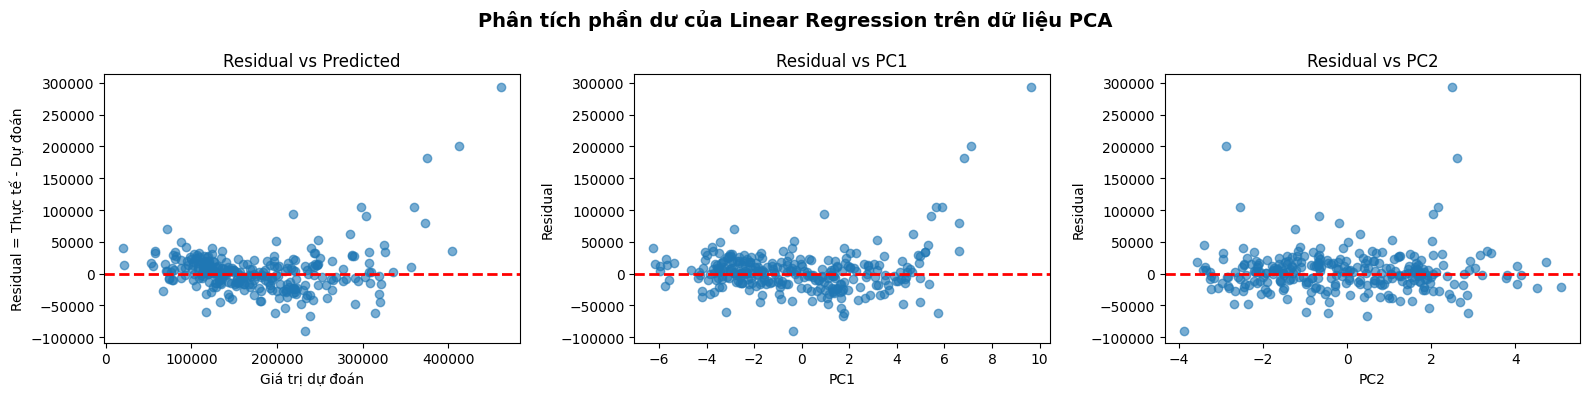

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

X_np = X_pca
y_np = Y.values


X_train, X_val, y_train, y_val = split_data(X_np, y_np, 0.2)


beta = train_linear(X_train, y_train)


y_train_pred = predict_linear(X_train, beta)
y_pred = predict_linear(X_val, beta)


residuals = y_val - y_pred


train_r2 = r2_score_manual(y_train, y_train_pred)
val_r2 = r2_score_manual(y_val, y_pred)
val_rmse = rmse(y_val, y_pred)
val_mae = mean_absolute_error(y_val, y_pred)

print("=== LINEAR REGRESSION TRÊN DỮ LIỆU PCA, TỈ LỆ 4:1 ===")
print(f"Train R2 : {train_r2:.4f}")
print(f"Val R2   : {val_r2:.4f}")
print(f"Val RMSE : {val_rmse:.2f}")
print(f"Val MAE  : {val_mae:.2f}")

plt.figure(figsize=(16, 4))

# --- (1) Residual vs Predicted ---
plt.subplot(1, 3, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Giá trị dự đoán")
plt.ylabel("Residual = Thực tế - Dự đoán")
plt.title("Residual vs Predicted")

# --- (2) Residual vs PC1 ---
plt.subplot(1, 3, 2)
plt.scatter(X_val[:, 0], residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("PC1")
plt.ylabel("Residual")
plt.title("Residual vs PC1")

# --- (3) Residual vs PC2 ---
plt.subplot(1, 3, 3)
plt.scatter(X_val[:, 1], residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("PC2")
plt.ylabel("Residual")
plt.title("Residual vs PC2")

plt.suptitle("Phân tích phần dư của Linear Regression trên dữ liệu PCA", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Multi Layers Perceptron

### (a)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

test_sizes = [0.2, 0.3, 0.4]

ratio_names = {
    0.2: "4:1",
    0.3: "7:3",
    0.4: "6:4"
}

def evaluate_mlp(X, Y, data_name):
    print(f"\n{'='*60}")
    print(f"ĐÁNH GIÁ MLP TRÊN: {data_name}")
    print(f"{'='*60}")

    if hasattr(Y, "values"):
        Y_array = Y.values.reshape(-1, 1)
    else:
        Y_array = np.asarray(Y).reshape(-1, 1)

    results = []

    for ts in test_sizes:
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            Y_array,
            test_size=ts,
            random_state=42
        )


        scaler_y = StandardScaler()
        y_train_scaled = scaler_y.fit_transform(y_train).ravel()

        print(f"\n--- Tỉ lệ Train:Validation = {ratio_names[ts]} ---")

        mlp_base = MLPRegressor(
            hidden_layer_sizes=(50,),
            max_iter=1000,
            alpha=0.0001,
            random_state=42
        )

        mlp_base.fit(X_train, y_train_scaled)

        pred_train_base_scaled = mlp_base.predict(X_train)
        pred_test_base_scaled = mlp_base.predict(X_test)

        pred_train_base = scaler_y.inverse_transform(
            pred_train_base_scaled.reshape(-1, 1)
        ).ravel()

        pred_test_base = scaler_y.inverse_transform(
            pred_test_base_scaled.reshape(-1, 1)
        ).ravel()

        train_r2_base = r2_score(y_train, pred_train_base)
        test_r2_base = r2_score(y_test, pred_test_base)
        gap_base = train_r2_base - test_r2_base
        test_rmse_base = np.sqrt(mean_squared_error(y_test, pred_test_base))

        print(
            f"MLP chưa hiệu chỉnh | "
            f"Train R2: {train_r2_base:.4f} | "
            f"Test R2: {test_r2_base:.4f} | "
            f"Gap: {gap_base:.4f} | "
            f"Test RMSE: {test_rmse_base:.2f}"
        )

        results.append({
            "Mô hình": "MLP chưa hiệu chỉnh",
            "Dữ liệu": data_name,
            "Tỉ lệ train:test": ratio_names[ts],
            "Alpha": 0.0001,
            "Early stopping": False,
            "Train R2": train_r2_base,
            "Test R2": test_r2_base,
            "Gap": gap_base,
            "Test RMSE": test_rmse_base
        })


        mlp_reg = MLPRegressor(
            hidden_layer_sizes=(50,),
            max_iter=1000,
            alpha=0.1,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=42
        )

        mlp_reg.fit(X_train, y_train_scaled)

        pred_train_reg_scaled = mlp_reg.predict(X_train)
        pred_test_reg_scaled = mlp_reg.predict(X_test)

        pred_train_reg = scaler_y.inverse_transform(
            pred_train_reg_scaled.reshape(-1, 1)
        ).ravel()

        pred_test_reg = scaler_y.inverse_transform(
            pred_test_reg_scaled.reshape(-1, 1)
        ).ravel()

        train_r2_reg = r2_score(y_train, pred_train_reg)
        test_r2_reg = r2_score(y_test, pred_test_reg)
        gap_reg = train_r2_reg - test_r2_reg
        test_rmse_reg = np.sqrt(mean_squared_error(y_test, pred_test_reg))

        print(
            f"MLP đã hiệu chỉnh   | "
            f"Train R2: {train_r2_reg:.4f} | "
            f"Test R2: {test_r2_reg:.4f} | "
            f"Gap: {gap_reg:.4f} | "
            f"Test RMSE: {test_rmse_reg:.2f}"
        )

        results.append({
            "Mô hình": "MLP đã hiệu chỉnh",
            "Dữ liệu": data_name,
            "Tỉ lệ train:test": ratio_names[ts],
            "Alpha": 0.1,
            "Early stopping": True,
            "Train R2": train_r2_reg,
            "Test R2": test_r2_reg,
            "Gap": gap_reg,
            "Test RMSE": test_rmse_reg
        })

    return pd.DataFrame(results)

### Với dữ liệu gốc

In [ ]:

evaluate_mlp(X_scaled, Y, "DỮ LIỆU GỐC (X_scaled)")


ĐÁNH GIÁ MLP TRÊN: DỮ LIỆU GỐC (X_scaled)

--- Tỉ lệ Train:Validation = 4:1 ---
MLP chưa hiệu chỉnh | Train R2: 0.9958 | Test R2: 0.8756 | Gap: 0.1202 | Test RMSE: 30895.67
MLP đã hiệu chỉnh   | Train R2: 0.6849 | Test R2: 0.7121 | Gap: -0.0272 | Test RMSE: 46991.76

--- Tỉ lệ Train:Validation = 7:3 ---
MLP chưa hiệu chỉnh | Train R2: 0.9972 | Test R2: 0.8762 | Gap: 0.1209 | Test RMSE: 29388.11
MLP đã hiệu chỉnh   | Train R2: 0.8770 | Test R2: 0.8470 | Gap: 0.0299 | Test RMSE: 32670.17

--- Tỉ lệ Train:Validation = 6:4 ---
MLP chưa hiệu chỉnh | Train R2: 0.9973 | Test R2: 0.8524 | Gap: 0.1449 | Test RMSE: 32712.07
MLP đã hiệu chỉnh   | Train R2: 0.9889 | Test R2: 0.8561 | Gap: 0.1328 | Test RMSE: 32299.89


,Mô hình,Dữ liệu,Tỉ lệ train:test,Alpha,Early stopping,Train R2,Test R2,Gap,Test RMSE
0,MLP chưa hiệu chỉnh,DỮ LIỆU GỐC (X_scaled),4:1,0.0001,False,0.995796,0.875554,0.120242,30895.673275
1,MLP đã hiệu chỉnh,DỮ LIỆU GỐC (X_scaled),4:1,0.1000,True,0.684924,0.712108,-0.027184,46991.762389
2,MLP chưa hiệu chỉnh,DỮ LIỆU GỐC (X_scaled),7:3,0.0001,False,0.997181,0.876233,0.120949,29388.112402
3,MLP đã hiệu chỉnh,DỮ LIỆU GỐC (X_scaled),7:3,0.1000,True,0.876970,0.847044,0.029926,32670.166089
4,MLP chưa hiệu chỉnh,DỮ LIỆU GỐC (X_scaled),6:4,0.0001,False,0.997293,0.852354,0.144939,32712.074981
5,MLP đã hiệu chỉnh,DỮ LIỆU GỐC (X_scaled),6:4,0.1000,True,0.988897,0.856052,0.132845,32299.888327


### Với dữ liệu giảm chiều

In [ ]:
evaluate_mlp(X_pca, Y, "DỮ LIỆU ĐÃ GIẢM CHIỀU (X_pca)")


ĐÁNH GIÁ MLP TRÊN: DỮ LIỆU ĐÃ GIẢM CHIỀU (X_pca)

--- Tỉ lệ Train:Validation = 4:1 ---
MLP chưa hiệu chỉnh | Train R2: 0.9827 | Test R2: 0.8480 | Gap: 0.1346 | Test RMSE: 34140.40
MLP đã hiệu chỉnh   | Train R2: 0.9543 | Test R2: 0.8480 | Gap: 0.1063 | Test RMSE: 34141.35

--- Tỉ lệ Train:Validation = 7:3 ---
MLP chưa hiệu chỉnh | Train R2: 0.9860 | Test R2: 0.8088 | Gap: 0.1772 | Test RMSE: 36522.45
MLP đã hiệu chỉnh   | Train R2: 0.5034 | Test R2: 0.4403 | Gap: 0.0631 | Test RMSE: 62492.99

--- Tỉ lệ Train:Validation = 6:4 ---
MLP chưa hiệu chỉnh | Train R2: 0.9853 | Test R2: 0.7798 | Gap: 0.2054 | Test RMSE: 39946.10
MLP đã hiệu chỉnh   | Train R2: 0.9620 | Test R2: 0.7584 | Gap: 0.2036 | Test RMSE: 41842.15


,Mô hình,Dữ liệu,Tỉ lệ train:test,Alpha,Early stopping,Train R2,Test R2,Gap,Test RMSE
0,MLP chưa hiệu chỉnh,DỮ LIỆU ĐÃ GIẢM CHIỀU (X_pca),4:1,0.0001,False,0.982690,0.848042,0.134648,34140.401235
1,MLP đã hiệu chỉnh,DỮ LIỆU ĐÃ GIẢM CHIỀU (X_pca),4:1,0.1000,True,0.954345,0.848034,0.106311,34141.351802
2,MLP chưa hiệu chỉnh,DỮ LIỆU ĐÃ GIẢM CHIỀU (X_pca),7:3,0.0001,False,0.986050,0.808846,0.177203,36522.450131
3,MLP đã hiệu chỉnh,DỮ LIỆU ĐÃ GIẢM CHIỀU (X_pca),7:3,0.1000,True,0.503443,0.440338,0.063105,62492.986044
4,MLP chưa hiệu chỉnh,DỮ LIỆU ĐÃ GIẢM CHIỀU (X_pca),6:4,0.0001,False,0.985257,0.779832,0.205425,39946.101294
5,MLP đã hiệu chỉnh,DỮ LIỆU ĐÃ GIẢM CHIỀU (X_pca),6:4,0.1000,True,0.961990,0.758436,0.203554,41842.148717


### (b)

Test R2: 0.8088461678417052
Test RMSE: 36522.45013089123


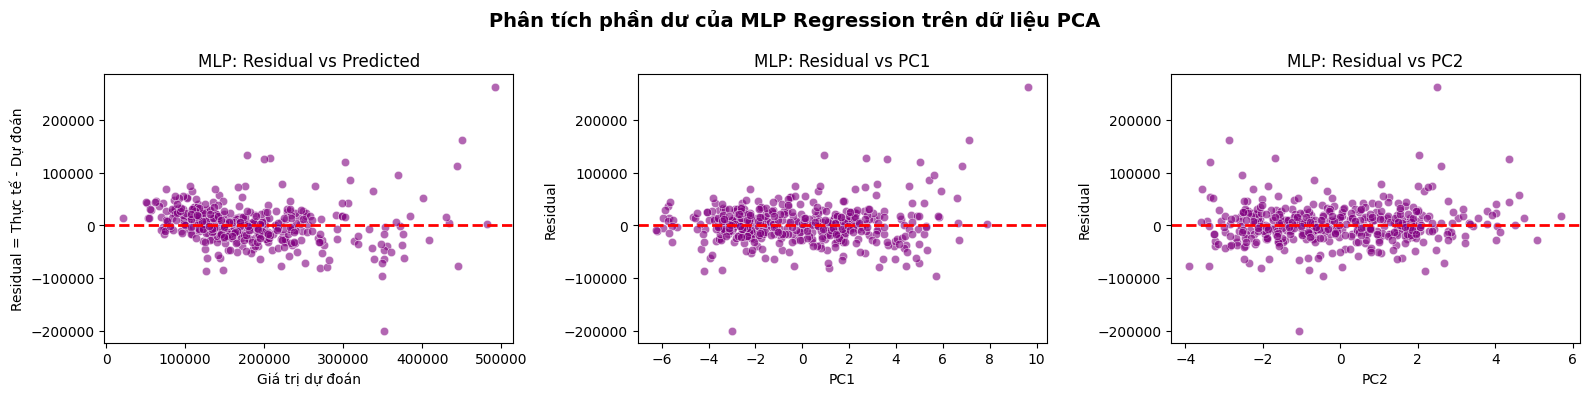

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    Y.values.reshape(-1, 1),
    test_size=0.3,
    random_state=42
)

# Scale y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train).ravel()

# Train MLP
mlp_best = MLPRegressor(
    hidden_layer_sizes=(50,),
    max_iter=1000,
    alpha=0.0001,
    random_state=42
)

mlp_best.fit(X_train, y_train_scaled)

# Predict và inverse scale
y_pred_scaled = mlp_best.predict(X_test)
y_pred_mlp = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).ravel()

y_test_real = y_test.ravel()

# Residual có dấu
residuals_mlp = y_test_real - y_pred_mlp

print("Test R2:", r2_score(y_test_real, y_pred_mlp))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_real, y_pred_mlp)))

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(x=y_pred_mlp, y=residuals_mlp, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Giá trị dự đoán")
plt.ylabel("Residual = Thực tế - Dự đoán")
plt.title("MLP: Residual vs Predicted")

plt.subplot(1, 3, 2)
sns.scatterplot(x=X_test[:, 0], y=residuals_mlp, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("PC1")
plt.ylabel("Residual")
plt.title("MLP: Residual vs PC1")

plt.subplot(1, 3, 3)
sns.scatterplot(x=X_test[:, 1], y=residuals_mlp, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("PC2")
plt.ylabel("Residual")
plt.title("MLP: Residual vs PC2")

plt.suptitle("Phân tích phần dư của MLP Regression trên dữ liệu PCA", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#(V) Phân loại

## Mối quan hệ giữa các cụm và đầu ra

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


y_price = pd.Series(Y).reset_index(drop=True)

df_price_cluster = pd.DataFrame({
    "SalePrice": y_price,
    "Cluster": labels_kmeans
})

print("===== THỐNG KÊ SALEPRICE THEO CỤM K-MEANS ĐÃ CÓ =====")

cluster_summary = df_price_cluster.groupby("Cluster")["SalePrice"].agg(
    So_mau="count",
    Gia_min="min",
    Q1=lambda x: x.quantile(0.25),
    Trung_vi="median",
    Gia_TB="mean",
    Q3=lambda x: x.quantile(0.75),
    Gia_max="max"
).sort_values("Trung_vi")

display(cluster_summary.round(2))

===== THỐNG KÊ SALEPRICE THEO CỤM K-MEANS ĐÃ CÓ =====


,So_mau,Gia_min,Q1,Trung_vi,Gia_TB,Q3,Gia_max
Cluster,,,,,,,
1,81,34900,82500.0,100000.0,103317.28,124000.0,200500
2,668,35311,116037.5,133950.0,133126.78,149387.5,250000
3,369,107500,179540.0,212000.0,233794.49,263000.0,755000
0,342,82500,184787.5,215000.0,235606.42,270000.0,611657


## Tìm ngưỡng chia

In [ ]:
def find_price_thresholds_by_cluster_and_balance(
    df,
    class_options=[3, 4],
    window_ratio=0.12
):
    required_cols = {"SalePrice", "Cluster"}
    if not required_cols.issubset(df.columns):
        raise ValueError("df phải có cột SalePrice và Cluster")

    df_sorted = df.sort_values("SalePrice").reset_index(drop=True).copy()
    n = len(df_sorted)

    best_result = None
    all_results = []

    for n_classes in class_options:
        ideal_positions = [
            int(n * i / n_classes)
            for i in range(1, n_classes)
        ]

        selected_positions = []

        for pos in ideal_positions:
            left = max(1, int(pos - window_ratio * n))
            right = min(n - 2, int(pos + window_ratio * n))

            candidate_scores = []

            for p in range(left, right + 1):
                left_clusters = df_sorted.loc[:p, "Cluster"]
                right_clusters = df_sorted.loc[p+1:, "Cluster"]

                left_purity = left_clusters.value_counts(normalize=True).max()
                right_purity = right_clusters.value_counts(normalize=True).max()

                boundary_change = int(
                    df_sorted.loc[p, "Cluster"] != df_sorted.loc[p+1, "Cluster"]
                )

                distance_penalty = abs(p - pos) / n

                score = (
                    left_purity
                    + right_purity
                    + 0.5 * boundary_change
                    - distance_penalty
                )

                candidate_scores.append((p, score))

            best_pos = max(candidate_scores, key=lambda x: x[1])[0]
            selected_positions.append(best_pos)

        selected_positions = sorted(list(set(selected_positions)))

        if len(selected_positions) != n_classes - 1:
            continue

        thresholds = []

        for p in selected_positions:
            t = (
                df_sorted.loc[p, "SalePrice"]
                + df_sorted.loc[p + 1, "SalePrice"]
            ) / 2
            thresholds.append(t)

        thresholds = np.array(thresholds)

        y_class_temp = np.digitize(df["SalePrice"], thresholds)

        counts = (
            pd.Series(y_class_temp)
            .value_counts()
            .reindex(range(n_classes), fill_value=0)
            .sort_index()
        )

        max_count = counts.max()
        min_count = counts.min()
        balance_ratio = min_count / max_count if max_count > 0 else 0

        crosstab = pd.crosstab(
            df["Cluster"],
            y_class_temp,
            normalize="index"
        )

        cluster_alignment = crosstab.max(axis=1).mean()

        final_score = balance_ratio + 0.35 * cluster_alignment

        result = {
            "n_classes": n_classes,
            "thresholds": thresholds,
            "y_class": y_class_temp,
            "counts": counts,
            "balance_ratio": balance_ratio,
            "cluster_alignment": cluster_alignment,
            "final_score": final_score,
            "crosstab": crosstab
        }

        all_results.append(result)

        if best_result is None or final_score > best_result["final_score"]:
            best_result = result

    return best_result, all_results

## CHỌN CÁCH CHIA TỐT NHẤT GIỮA 3 VÀ 4 KHOẢNG

In [ ]:
best_split, all_splits = find_price_thresholds_by_cluster_and_balance(
    df_price_cluster,
    class_options=[3, 4],
    window_ratio=0.12
)

print("===== SO SÁNH CÁC PHƯƠNG ÁN CHIA =====")

for result in all_splits:
    print("\n" + "-" * 60)
    print(f"Số lớp: {result['n_classes']}")
    print(f"Tỉ lệ cân bằng min/max: {result['balance_ratio']:.4f}")
    print(f"Mức phù hợp với cụm K-Means: {result['cluster_alignment']:.4f}")
    print(f"Điểm tổng hợp: {result['final_score']:.4f}")

    print("\nNgưỡng chia:")
    for i, t in enumerate(result["thresholds"]):
        print(f"Ngưỡng {i + 1}: {t:,.0f}")

    print("\nSố mẫu từng lớp:")
    display(result["counts"].to_frame("Số mẫu"))

print("\n" + "=" * 70)
print("PHƯƠNG ÁN ĐƯỢC CHỌN")
print("=" * 70)

N_CLASSES = best_split["n_classes"]
price_thresholds = best_split["thresholds"]

y_class = pd.Series(
    best_split["y_class"],
    name="PriceClass"
)

print(f"Số lớp được chọn: {N_CLASSES}")

print("\nCác ngưỡng chia SalePrice:")
for i, t in enumerate(price_thresholds):
    print(f"Ngưỡng {i + 1}: {t:,.0f}")

print("\nSố lượng mẫu trong từng lớp:")
display(y_class.value_counts().sort_index().to_frame("Số mẫu"))

class_names = [f"Lớp {i}" for i in range(N_CLASSES)]

===== SO SÁNH CÁC PHƯƠNG ÁN CHIA =====

------------------------------------------------------------
Số lớp: 3
Tỉ lệ cân bằng min/max: 0.7719
Mức phù hợp với cụm K-Means: 0.7429
Điểm tổng hợp: 1.0319

Ngưỡng chia:
Ngưỡng 1: 140,000
Ngưỡng 2: 182,950

Số mẫu từng lớp:


,Số mẫu
0,489
1,423
2,548



------------------------------------------------------------
Số lớp: 4
Tỉ lệ cân bằng min/max: 0.9837
Mức phù hợp với cụm K-Means: 0.5665
Điểm tổng hợp: 1.1819

Ngưỡng chia:
Ngưỡng 1: 130,000
Ngưỡng 2: 163,500
Ngưỡng 3: 214,000

Số mẫu từng lớp:


,Số mẫu
0,365
1,367
2,361
3,367



PHƯƠNG ÁN ĐƯỢC CHỌN
Số lớp được chọn: 4

Các ngưỡng chia SalePrice:
Ngưỡng 1: 130,000
Ngưỡng 2: 163,500
Ngưỡng 3: 214,000

Số lượng mẫu trong từng lớp:


,Số mẫu
PriceClass,
0,365
1,367
2,361
3,367


## GÁN TÊN NHÃN

In [ ]:
if N_CLASSES == 3:
    label_names = {
        0: "Giá thấp",
        1: "Giá trung bình",
        2: "Giá cao"
    }
else:
    label_names = {
        0: "Giá thấp",
        1: "Giá trung bình thấp",
        2: "Giá trung bình cao",
        3: "Giá cao"
    }

df_class_info = pd.DataFrame({
    "SalePrice": y_price,
    "PriceClass": y_class,
    "Ten_lop": y_class.map(label_names),
    "Cluster_KMeans": labels_kmeans
})

print("===== 10 DÒNG ĐẦU SAU KHI CHUYỂN THÀNH BÀI TOÁN PHÂN LOẠI =====")
display(df_class_info.head(10))

print("\n===== THỐNG KÊ SALEPRICE THEO LỚP GIÁ MỚI =====")
display(
    df_class_info.groupby(["PriceClass", "Ten_lop"])["SalePrice"].agg(
        So_mau="count",
        Gia_min="min",
        Gia_TB="mean",
        Trung_vi="median",
        Gia_max="max"
    ).round(2)
)

===== 10 DÒNG ĐẦU SAU KHI CHUYỂN THÀNH BÀI TOÁN PHÂN LOẠI =====


,SalePrice,PriceClass,Ten_lop,Cluster_KMeans
0,208500,2,Giá trung bình cao,3
1,181500,2,Giá trung bình cao,2
2,223500,3,Giá cao,3
3,140000,1,Giá trung bình thấp,2
4,250000,3,Giá cao,3
5,143000,1,Giá trung bình thấp,2
6,307000,3,Giá cao,0
7,200000,2,Giá trung bình cao,3
8,129900,0,Giá thấp,2
9,118000,0,Giá thấp,2



===== THỐNG KÊ SALEPRICE THEO LỚP GIÁ MỚI =====


,,So_mau,Gia_min,Gia_TB,Trung_vi,Gia_max
PriceClass,Ten_lop,,,,,
0,Giá thấp,365,34900,105831.59,110000.0,129900
1,Giá trung bình thấp,367,130000,145041.89,144000.0,163000
2,Giá trung bình cao,361,163500,184863.61,183000.0,213500
3,Giá cao,367,214000,287602.94,263435.0,755000


## TRỰC QUAN HÓA

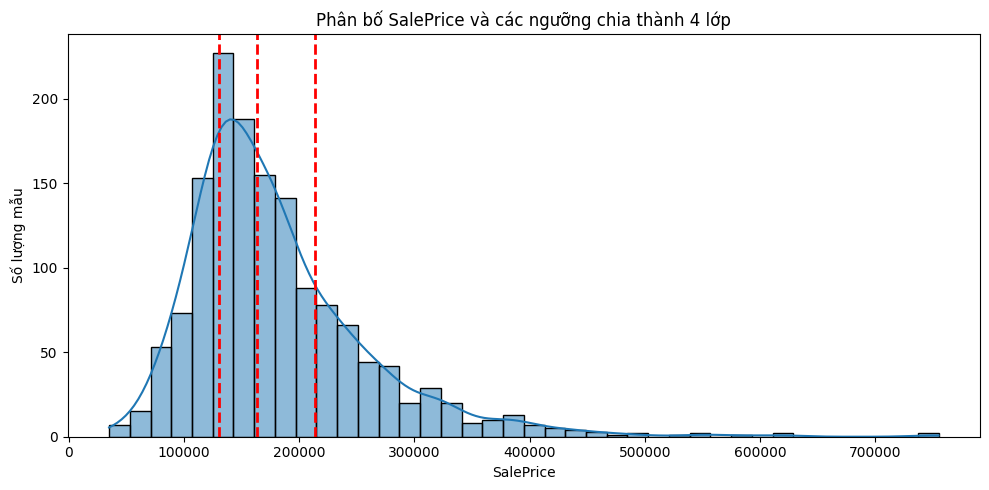

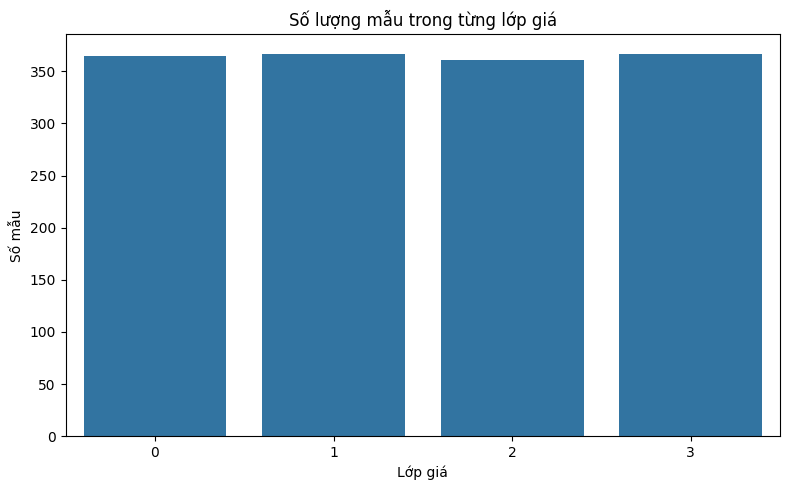

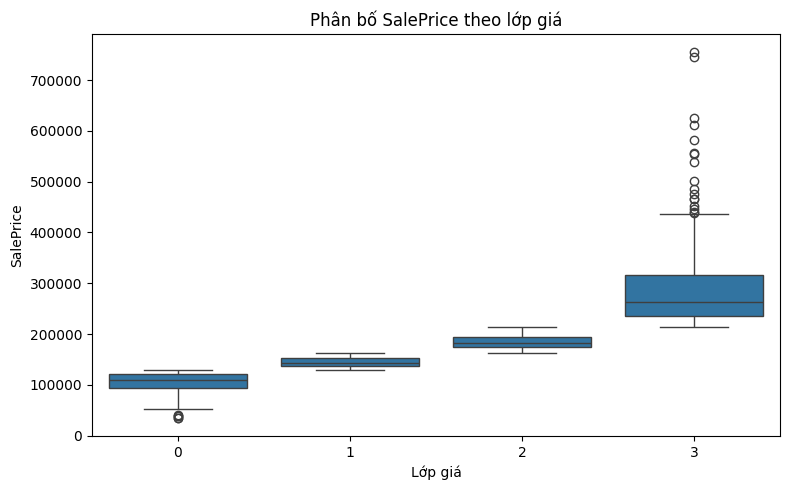

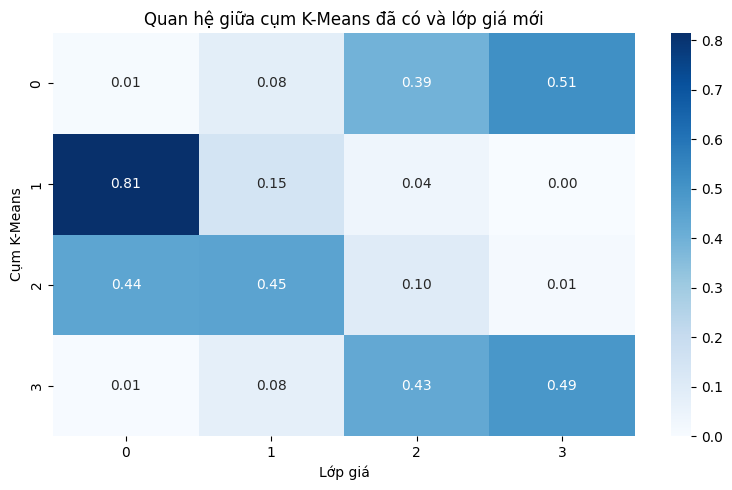

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(y_price, bins=40, kde=True)

for threshold in price_thresholds:
    plt.axvline(threshold, color="red", linestyle="--", linewidth=2)

plt.title(f"Phân bố SalePrice và các ngưỡng chia thành {N_CLASSES} lớp")
plt.xlabel("SalePrice")
plt.ylabel("Số lượng mẫu")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.countplot(x=y_class)
plt.title("Số lượng mẫu trong từng lớp giá")
plt.xlabel("Lớp giá")
plt.ylabel("Số mẫu")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(data=df_class_info, x="PriceClass", y="SalePrice")
plt.title("Phân bố SalePrice theo lớp giá")
plt.xlabel("Lớp giá")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.heatmap(
    pd.crosstab(df_class_info["Cluster_KMeans"], df_class_info["PriceClass"], normalize="index"),
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title("Quan hệ giữa cụm K-Means đã có và lớp giá mới")
plt.xlabel("Lớp giá")
plt.ylabel("Cụm K-Means")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA

X_original = X_scaled.values if hasattr(X_scaled, "values") else X_scaled

n_original_features = X_original.shape[1]
n_components_13 = int(np.ceil(n_original_features / 3))

print("Số chiều dữ liệu gốc:", n_original_features)
print("Số chiều dữ liệu giảm chiều 1/3:", n_components_13)

pca_classification = PCA(
    n_components=n_components_13,
    random_state=42
)

X_reduced_13 = pca_classification.fit_transform(X_original)

print("Kích thước dữ liệu gốc:", X_original.shape)
print("Kích thước dữ liệu giảm chiều:", X_reduced_13.shape)
print(f"Tổng phương sai giữ lại: {pca_classification.explained_variance_ratio_.sum() * 100:.2f}%")

Số chiều dữ liệu gốc: 281
Số chiều dữ liệu giảm chiều 1/3: 94
Kích thước dữ liệu gốc: (1460, 281)
Kích thước dữ liệu giảm chiều: (1460, 94)
Tổng phương sai giữ lại: 96.37%


In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
models = {
    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="uniform",
        metric="minkowski",
        p=2
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "Multinomial Logistic Regression": LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=5000,
        random_state=42
    )
}

In [ ]:
test_sizes = [0.2, 0.3, 0.4]


def evaluate_classification(X_data, y_data, data_name):
    results = []

    print("\n" + "=" * 90)
    print(f"ĐÁNH GIÁ PHÂN LOẠI TRÊN: {data_name}")
    print("=" * 90)

    for test_size in test_sizes:
        train_ratio = int((1 - test_size) * 10)
        test_ratio = int(test_size * 10)

        X_train, X_test, y_train, y_test = train_test_split(
            X_data,
            y_data,
            test_size=test_size,
            random_state=42,
            stratify=y_data
        )

        print("\n" + "-" * 90)
        print(f"Tỉ lệ Train : Test = {train_ratio}:{test_ratio}")
        print("-" * 90)

        for model_name, model in models.items():
            model.fit(X_train, y_train)

            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

            train_acc = accuracy_score(y_train, y_train_pred)
            test_acc = accuracy_score(y_test, y_test_pred)

            train_f1 = f1_score(y_train, y_train_pred, average="macro")
            test_f1 = f1_score(y_test, y_test_pred, average="macro")

            test_precision = precision_score(
                y_test,
                y_test_pred,
                average="macro",
                zero_division=0
            )

            test_recall = recall_score(
                y_test,
                y_test_pred,
                average="macro",
                zero_division=0
            )

            results.append({
                "Dữ liệu": data_name,
                "Train:Test": f"{train_ratio}:{test_ratio}",
                "Mô hình": model_name,
                "Train Accuracy": train_acc,
                "Test Accuracy": test_acc,
                "Train Macro F1": train_f1,
                "Test Macro F1": test_f1,
                "Test Precision": test_precision,
                "Test Recall": test_recall
            })

            print(f"\nMô hình: {model_name}")
            print(f"Train Accuracy : {train_acc:.4f}")
            print(f"Test Accuracy  : {test_acc:.4f}")
            print(f"Train Macro F1 : {train_f1:.4f}")
            print(f"Test Macro F1  : {test_f1:.4f}")
            print(f"Test Precision : {test_precision:.4f}")
            print(f"Test Recall    : {test_recall:.4f}")

            print("\nClassification report:")
            print(
                classification_report(
                    y_test,
                    y_test_pred,
                    target_names=class_names,
                    zero_division=0
                )
            )

            cm = confusion_matrix(y_test, y_test_pred)

            plt.figure(figsize=(6, 4))
            sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names
            )
            plt.title(f"{model_name} - {data_name} - Train:Test {train_ratio}:{test_ratio}")
            plt.xlabel("Nhãn dự đoán")
            plt.ylabel("Nhãn thực tế")
            plt.tight_layout()
            plt.show()

    return pd.DataFrame(results)

## Thực hiện trên dữ liệu gốc


ĐÁNH GIÁ PHÂN LOẠI TRÊN: Dữ liệu gốc

------------------------------------------------------------------------------------------
Tỉ lệ Train : Test = 8:2
------------------------------------------------------------------------------------------

Mô hình: KNN
Train Accuracy : 0.7705
Test Accuracy  : 0.7158
Train Macro F1 : 0.7706
Test Macro F1  : 0.7160
Test Precision : 0.7245
Test Recall    : 0.7159

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.71      0.84      0.77        73
       Lớp 1       0.69      0.65      0.67        74
       Lớp 2       0.64      0.69      0.67        72
       Lớp 3       0.86      0.68      0.76        73

    accuracy                           0.72       292
   macro avg       0.72      0.72      0.72       292
weighted avg       0.72      0.72      0.72       292



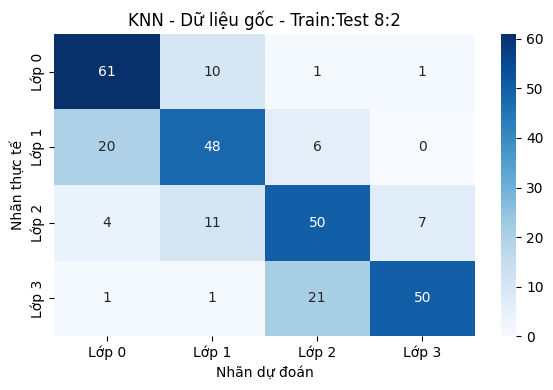


Mô hình: Gaussian Naive Bayes
Train Accuracy : 0.5128
Test Accuracy  : 0.4897
Train Macro F1 : 0.4681
Test Macro F1  : 0.4426
Test Precision : 0.5549
Test Recall    : 0.4884

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.86      0.42      0.57        73
       Lớp 1       0.48      0.47      0.48        74
       Lớp 2       0.46      0.08      0.14        72
       Lớp 3       0.42      0.97      0.58        73

    accuracy                           0.49       292
   macro avg       0.55      0.49      0.44       292
weighted avg       0.55      0.49      0.44       292



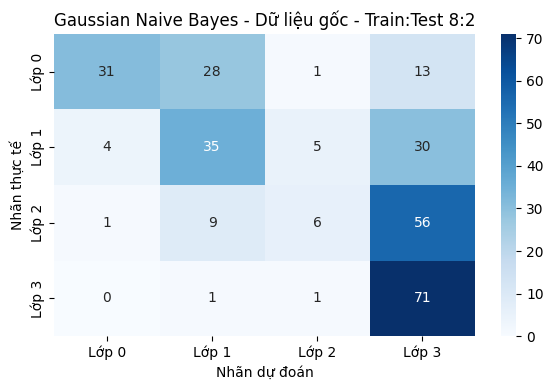

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Mô hình: Multinomial Logistic Regression
Train Accuracy : 0.9110
Test Accuracy  : 0.7774
Train Macro F1 : 0.9110
Test Macro F1  : 0.7780
Test Precision : 0.7796
Test Recall    : 0.7776

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.85      0.84      0.84        73
       Lớp 1       0.73      0.69      0.71        74
       Lớp 2       0.68      0.75      0.72        72
       Lớp 3       0.86      0.84      0.85        73

    accuracy                           0.78       292
   macro avg       0.78      0.78      0.78       292
weighted avg       0.78      0.78      0.78       292



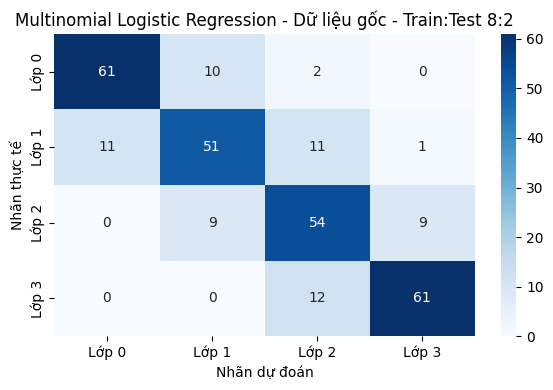


------------------------------------------------------------------------------------------
Tỉ lệ Train : Test = 7:3
------------------------------------------------------------------------------------------

Mô hình: KNN
Train Accuracy : 0.7701
Test Accuracy  : 0.7329
Train Macro F1 : 0.7702
Test Macro F1  : 0.7330
Test Precision : 0.7374
Test Recall    : 0.7326

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.73      0.84      0.78       110
       Lớp 1       0.66      0.66      0.66       110
       Lớp 2       0.68      0.68      0.68       108
       Lớp 3       0.87      0.75      0.81       110

    accuracy                           0.73       438
   macro avg       0.74      0.73      0.73       438
weighted avg       0.74      0.73      0.73       438



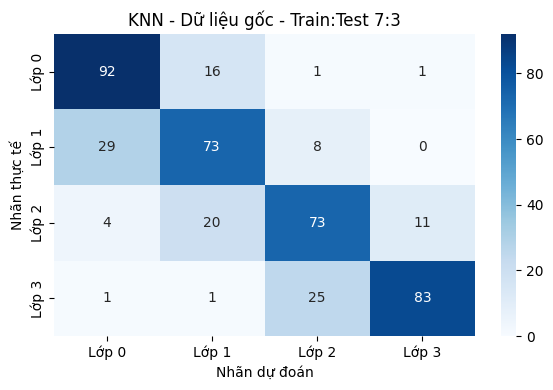


Mô hình: Gaussian Naive Bayes
Train Accuracy : 0.5147
Test Accuracy  : 0.4703
Train Macro F1 : 0.4762
Test Macro F1  : 0.4204
Test Precision : 0.5232
Test Recall    : 0.4684

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.88      0.41      0.56       110
       Lớp 1       0.48      0.45      0.47       110
       Lớp 2       0.33      0.06      0.10       108
       Lớp 3       0.40      0.95      0.56       110

    accuracy                           0.47       438
   macro avg       0.52      0.47      0.42       438
weighted avg       0.52      0.47      0.42       438



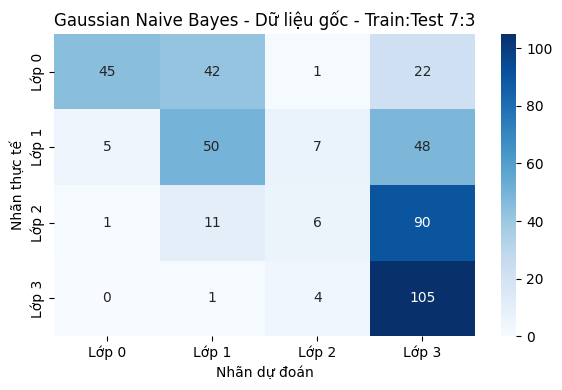

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Mô hình: Multinomial Logistic Regression
Train Accuracy : 0.9119
Test Accuracy  : 0.7626
Train Macro F1 : 0.9118
Test Macro F1  : 0.7633
Test Precision : 0.7652
Test Recall    : 0.7625

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.83      0.78      0.80       110
       Lớp 1       0.67      0.66      0.67       110
       Lớp 2       0.69      0.76      0.73       108
       Lớp 3       0.87      0.85      0.86       110

    accuracy                           0.76       438
   macro avg       0.77      0.76      0.76       438
weighted avg       0.77      0.76      0.76       438



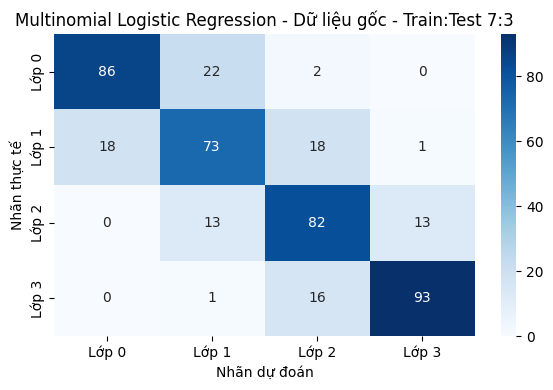


------------------------------------------------------------------------------------------
Tỉ lệ Train : Test = 6:4
------------------------------------------------------------------------------------------

Mô hình: KNN
Train Accuracy : 0.7717
Test Accuracy  : 0.7140
Train Macro F1 : 0.7723
Test Macro F1  : 0.7140
Test Precision : 0.7202
Test Recall    : 0.7142

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.72      0.84      0.78       146
       Lớp 1       0.62      0.57      0.59       147
       Lớp 2       0.65      0.69      0.67       144
       Lớp 3       0.89      0.75      0.81       147

    accuracy                           0.71       584
   macro avg       0.72      0.71      0.71       584
weighted avg       0.72      0.71      0.71       584



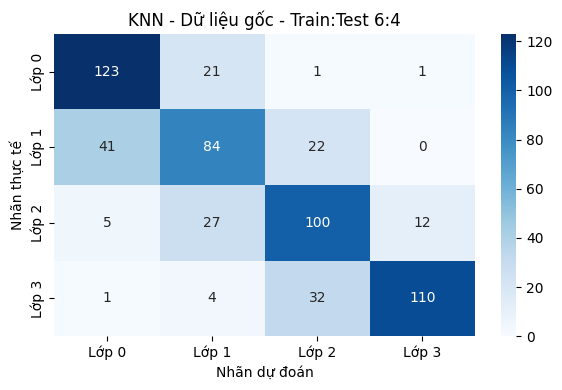


Mô hình: Gaussian Naive Bayes
Train Accuracy : 0.5411
Test Accuracy  : 0.4777
Train Macro F1 : 0.5083
Test Macro F1  : 0.4403
Test Precision : 0.5475
Test Recall    : 0.4758

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.86      0.49      0.62       146
       Lớp 1       0.51      0.38      0.44       147
       Lớp 2       0.44      0.10      0.16       144
       Lớp 3       0.38      0.94      0.54       147

    accuracy                           0.48       584
   macro avg       0.55      0.48      0.44       584
weighted avg       0.55      0.48      0.44       584



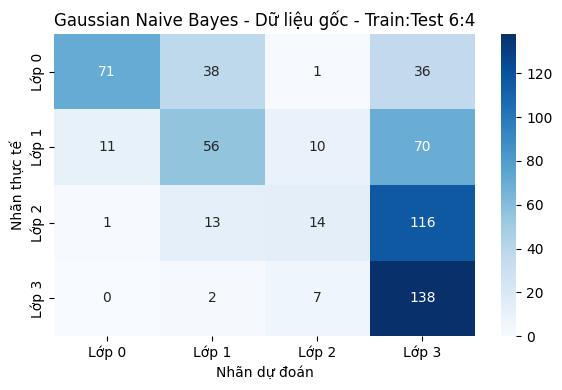

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Mô hình: Multinomial Logistic Regression
Train Accuracy : 0.9258
Test Accuracy  : 0.7312
Train Macro F1 : 0.9256
Test Macro F1  : 0.7334
Test Precision : 0.7381
Test Recall    : 0.7311

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.84      0.75      0.79       146
       Lớp 1       0.61      0.63      0.62       147
       Lớp 2       0.65      0.72      0.68       144
       Lớp 3       0.85      0.82      0.84       147

    accuracy                           0.73       584
   macro avg       0.74      0.73      0.73       584
weighted avg       0.74      0.73      0.73       584



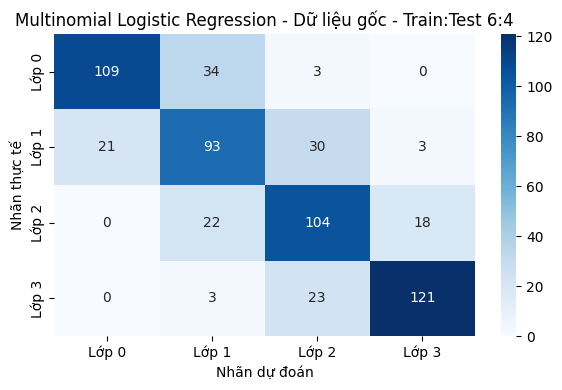

In [ ]:
results_original = evaluate_classification(
    X_original,
    y_class,
    "Dữ liệu gốc"
)

## Thực hiện trên dữ liệu giảm chiều


ĐÁNH GIÁ PHÂN LOẠI TRÊN: Dữ liệu giảm chiều PCA 1/3

------------------------------------------------------------------------------------------
Tỉ lệ Train : Test = 8:2
------------------------------------------------------------------------------------------

Mô hình: KNN
Train Accuracy : 0.7774
Test Accuracy  : 0.7158
Train Macro F1 : 0.7773
Test Macro F1  : 0.7156
Test Precision : 0.7240
Test Recall    : 0.7160

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.73      0.86      0.79        73
       Lớp 1       0.69      0.62      0.65        74
       Lớp 2       0.61      0.68      0.64        72
       Lớp 3       0.86      0.70      0.77        73

    accuracy                           0.72       292
   macro avg       0.72      0.72      0.72       292
weighted avg       0.72      0.72      0.72       292



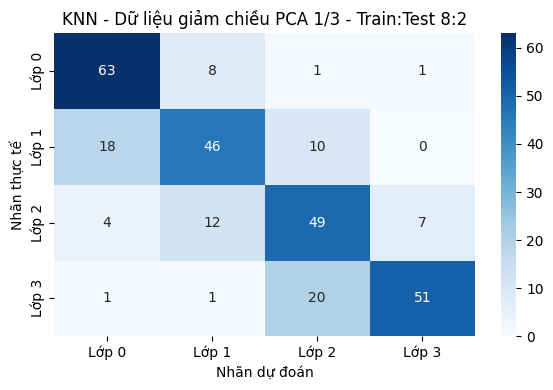


Mô hình: Gaussian Naive Bayes
Train Accuracy : 0.7295
Test Accuracy  : 0.6747
Train Macro F1 : 0.7303
Test Macro F1  : 0.6801
Test Precision : 0.6948
Test Recall    : 0.6753

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.73      0.71      0.72        73
       Lớp 1       0.51      0.55      0.53        74
       Lớp 2       0.62      0.74      0.68        72
       Lớp 3       0.91      0.70      0.79        73

    accuracy                           0.67       292
   macro avg       0.69      0.68      0.68       292
weighted avg       0.69      0.67      0.68       292



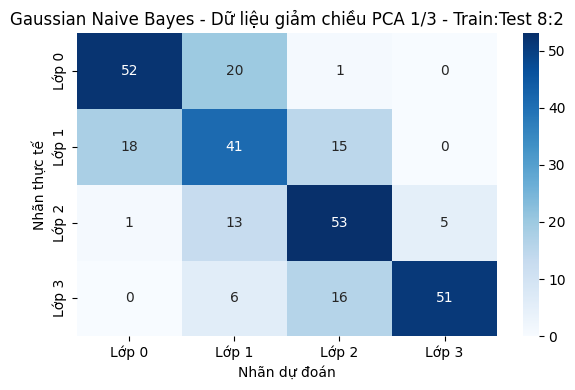

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Mô hình: Multinomial Logistic Regression
Train Accuracy : 0.8622
Test Accuracy  : 0.7637
Train Macro F1 : 0.8624
Test Macro F1  : 0.7660
Test Precision : 0.7712
Test Recall    : 0.7640

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.86      0.81      0.83        73
       Lớp 1       0.69      0.68      0.68        74
       Lớp 2       0.65      0.76      0.71        72
       Lớp 3       0.88      0.81      0.84        73

    accuracy                           0.76       292
   macro avg       0.77      0.76      0.77       292
weighted avg       0.77      0.76      0.77       292



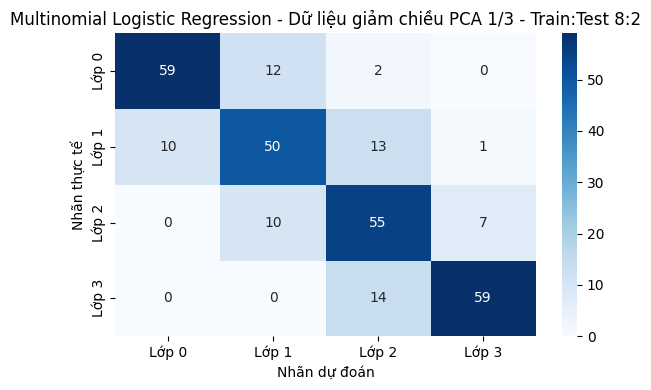


------------------------------------------------------------------------------------------
Tỉ lệ Train : Test = 7:3
------------------------------------------------------------------------------------------

Mô hình: KNN
Train Accuracy : 0.7808
Test Accuracy  : 0.7352
Train Macro F1 : 0.7806
Test Macro F1  : 0.7350
Test Precision : 0.7394
Test Recall    : 0.7349

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.73      0.85      0.78       110
       Lớp 1       0.67      0.65      0.66       110
       Lớp 2       0.68      0.69      0.68       108
       Lớp 3       0.87      0.75      0.81       110

    accuracy                           0.74       438
   macro avg       0.74      0.73      0.74       438
weighted avg       0.74      0.74      0.74       438



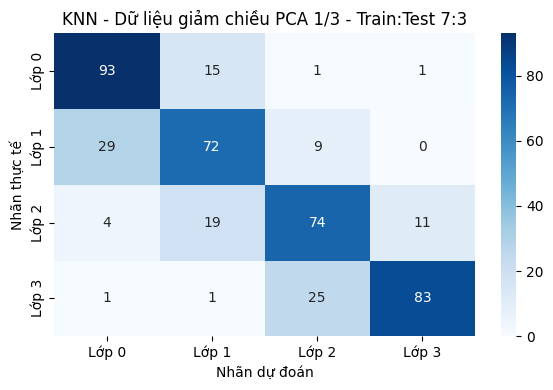


Mô hình: Gaussian Naive Bayes
Train Accuracy : 0.7368
Test Accuracy  : 0.6644
Train Macro F1 : 0.7368
Test Macro F1  : 0.6657
Test Precision : 0.6682
Test Recall    : 0.6643

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.70      0.73      0.71       110
       Lớp 1       0.53      0.54      0.53       110
       Lớp 2       0.62      0.65      0.63       108
       Lớp 3       0.82      0.75      0.78       110

    accuracy                           0.66       438
   macro avg       0.67      0.66      0.67       438
weighted avg       0.67      0.66      0.67       438



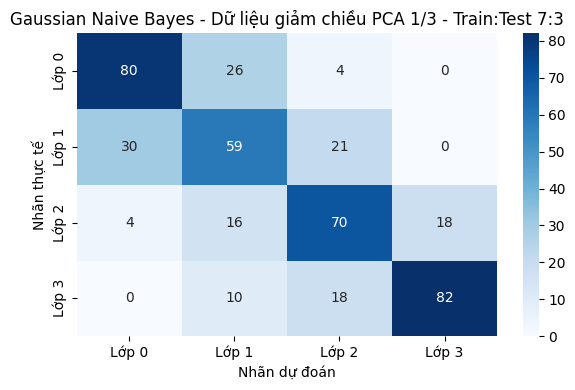

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Mô hình: Multinomial Logistic Regression
Train Accuracy : 0.8630
Test Accuracy  : 0.7648
Train Macro F1 : 0.8631
Test Macro F1  : 0.7654
Test Precision : 0.7674
Test Recall    : 0.7648

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.84      0.80      0.82       110
       Lớp 1       0.70      0.66      0.68       110
       Lớp 2       0.68      0.75      0.71       108
       Lớp 3       0.86      0.85      0.85       110

    accuracy                           0.76       438
   macro avg       0.77      0.76      0.77       438
weighted avg       0.77      0.76      0.77       438



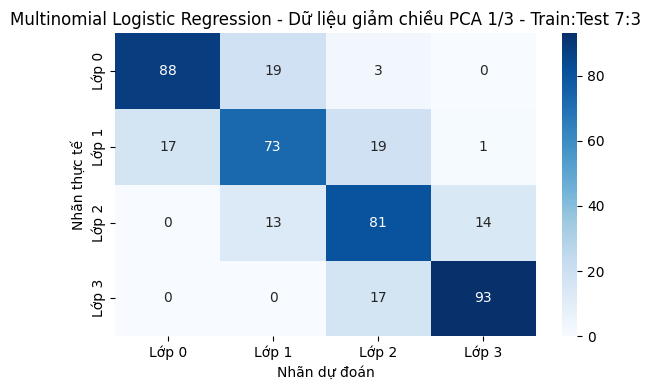


------------------------------------------------------------------------------------------
Tỉ lệ Train : Test = 6:4
------------------------------------------------------------------------------------------

Mô hình: KNN
Train Accuracy : 0.7763
Test Accuracy  : 0.7140
Train Macro F1 : 0.7761
Test Macro F1  : 0.7134
Test Precision : 0.7194
Test Recall    : 0.7142

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.73      0.85      0.78       146
       Lớp 1       0.61      0.55      0.58       147
       Lớp 2       0.64      0.70      0.67       144
       Lớp 3       0.90      0.76      0.82       147

    accuracy                           0.71       584
   macro avg       0.72      0.71      0.71       584
weighted avg       0.72      0.71      0.71       584



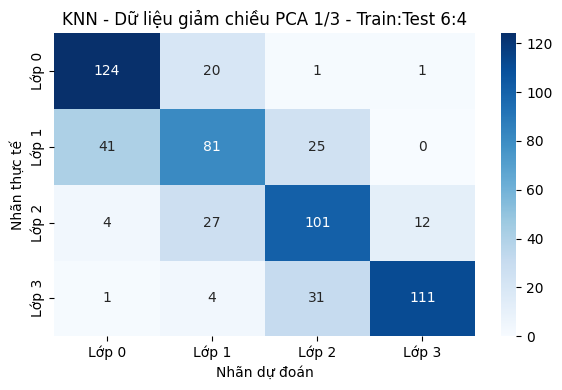


Mô hình: Gaussian Naive Bayes
Train Accuracy : 0.7295
Test Accuracy  : 0.6524
Train Macro F1 : 0.7280
Test Macro F1  : 0.6548
Test Precision : 0.6650
Test Recall    : 0.6527

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.73      0.77      0.75       146
       Lớp 1       0.48      0.45      0.46       147
       Lớp 2       0.56      0.68      0.61       144
       Lớp 3       0.89      0.71      0.79       147

    accuracy                           0.65       584
   macro avg       0.67      0.65      0.65       584
weighted avg       0.67      0.65      0.65       584



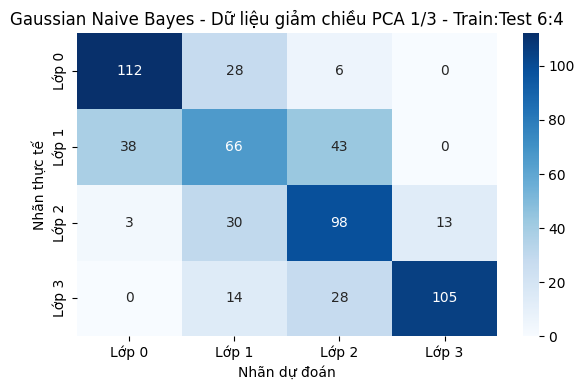

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Mô hình: Multinomial Logistic Regression
Train Accuracy : 0.8699
Test Accuracy  : 0.7449
Train Macro F1 : 0.8703
Test Macro F1  : 0.7467
Test Precision : 0.7507
Test Recall    : 0.7447

Classification report:
              precision    recall  f1-score   support

       Lớp 0       0.85      0.75      0.80       146
       Lớp 1       0.63      0.68      0.66       147
       Lớp 2       0.68      0.71      0.69       144
       Lớp 3       0.85      0.84      0.84       147

    accuracy                           0.74       584
   macro avg       0.75      0.74      0.75       584
weighted avg       0.75      0.74      0.75       584



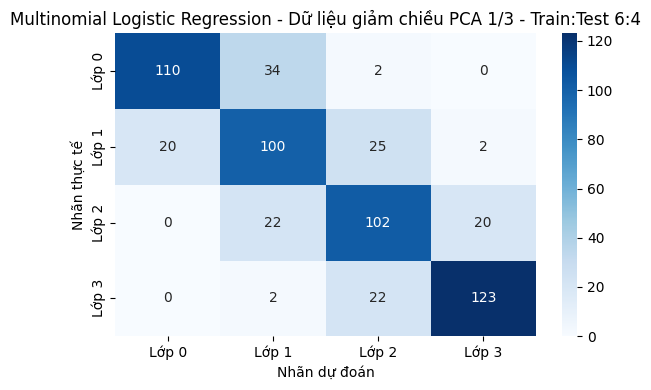

In [ ]:
results_reduced = evaluate_classification(
    X_reduced_13,
    y_class,
    "Dữ liệu giảm chiều PCA 1/3"
)

In [ ]:
classification_results = pd.concat(
    [results_original, results_reduced],
    ignore_index=True
)

print("===== BẢNG TỔNG HỢP KẾT QUẢ PHÂN LOẠI =====")
display(classification_results.round(4))

print("===== SẮP XẾP THEO TEST MACRO F1 =====")
display(
    classification_results
    .sort_values(by="Test Macro F1", ascending=False)
    .round(4)
)

===== BẢNG TỔNG HỢP KẾT QUẢ PHÂN LOẠI =====


,Dữ liệu,Train:Test,Mô hình,Train Accuracy,Test Accuracy,Train Macro F1,Test Macro F1,Test Precision,Test Recall
0,Dữ liệu gốc,8:2,KNN,0.7705,0.7158,0.7706,0.7160,0.7245,0.7159
1,Dữ liệu gốc,8:2,Gaussian Naive Bayes,0.5128,0.4897,0.4681,0.4426,0.5549,0.4884
2,Dữ liệu gốc,8:2,Multinomial Logistic Regression,0.9110,0.7774,0.9110,0.7780,0.7796,0.7776
3,Dữ liệu gốc,7:3,KNN,0.7701,0.7329,0.7702,0.7330,0.7374,0.7326
4,Dữ liệu gốc,7:3,Gaussian Naive Bayes,0.5147,0.4703,0.4762,0.4204,0.5232,0.4684
5,Dữ liệu gốc,7:3,Multinomial Logistic Regression,0.9119,0.7626,0.9118,0.7633,0.7652,0.7625
6,Dữ liệu gốc,6:4,KNN,0.7717,0.7140,0.7723,0.7140,0.7202,0.7142
7,Dữ liệu gốc,6:4,Gaussian Naive Bayes,0.5411,0.4777,0.5083,0.4403,0.5475,0.4758
8,Dữ liệu gốc,6:4,Multinomial Logistic Regression,0.9258,0.7312,0.9256,0.7334,0.7381,0.7311
9,Dữ liệu giảm chiều PCA 1/3,8:2,KNN,0.7774,0.7158,0.7773,0.7156,0.7240,0.7160


===== SẮP XẾP THEO TEST MACRO F1 =====


,Dữ liệu,Train:Test,Mô hình,Train Accuracy,Test Accuracy,Train Macro F1,Test Macro F1,Test Precision,Test Recall
2,Dữ liệu gốc,8:2,Multinomial Logistic Regression,0.9110,0.7774,0.9110,0.7780,0.7796,0.7776
11,Dữ liệu giảm chiều PCA 1/3,8:2,Multinomial Logistic Regression,0.8622,0.7637,0.8624,0.7660,0.7712,0.7640
14,Dữ liệu giảm chiều PCA 1/3,7:3,Multinomial Logistic Regression,0.8630,0.7648,0.8631,0.7654,0.7674,0.7648
5,Dữ liệu gốc,7:3,Multinomial Logistic Regression,0.9119,0.7626,0.9118,0.7633,0.7652,0.7625
17,Dữ liệu giảm chiều PCA 1/3,6:4,Multinomial Logistic Regression,0.8699,0.7449,0.8703,0.7467,0.7507,0.7447
12,Dữ liệu giảm chiều PCA 1/3,7:3,KNN,0.7808,0.7352,0.7806,0.7350,0.7394,0.7349
8,Dữ liệu gốc,6:4,Multinomial Logistic Regression,0.9258,0.7312,0.9256,0.7334,0.7381,0.7311
3,Dữ liệu gốc,7:3,KNN,0.7701,0.7329,0.7702,0.7330,0.7374,0.7326
0,Dữ liệu gốc,8:2,KNN,0.7705,0.7158,0.7706,0.7160,0.7245,0.7159
9,Dữ liệu giảm chiều PCA 1/3,8:2,KNN,0.7774,0.7158,0.7773,0.7156,0.7240,0.7160


## So sánh giữa các mô hình

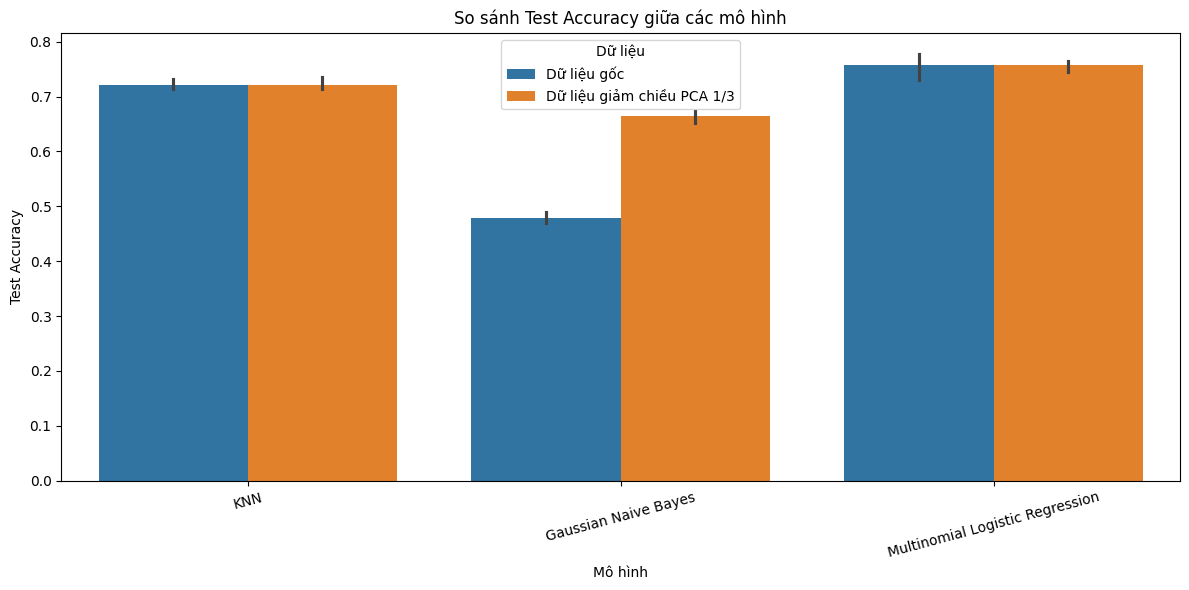

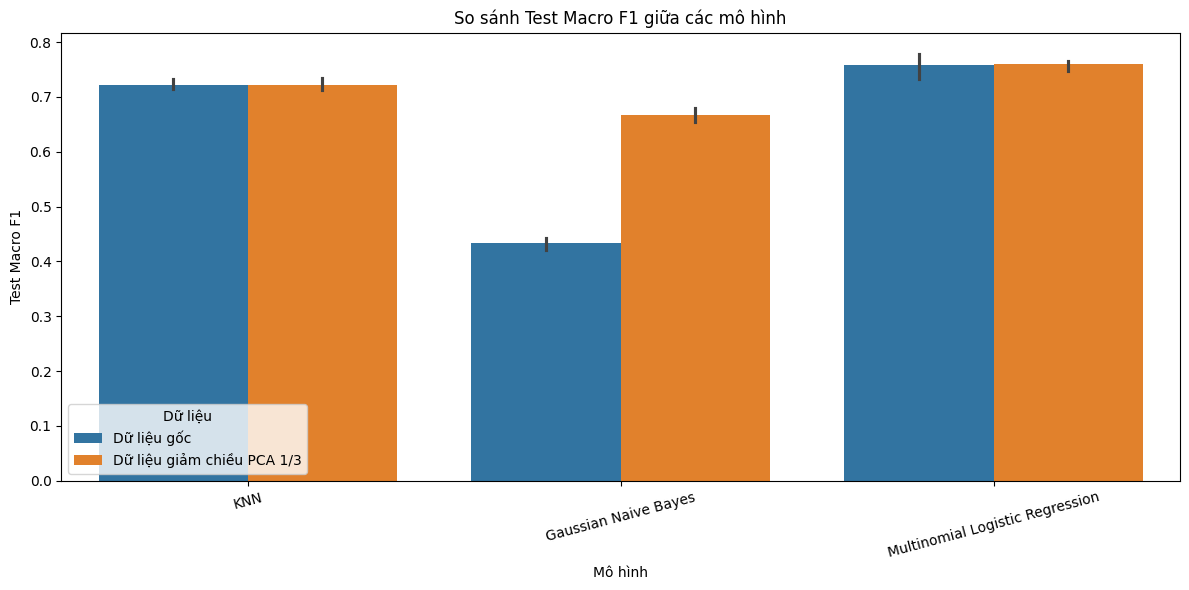

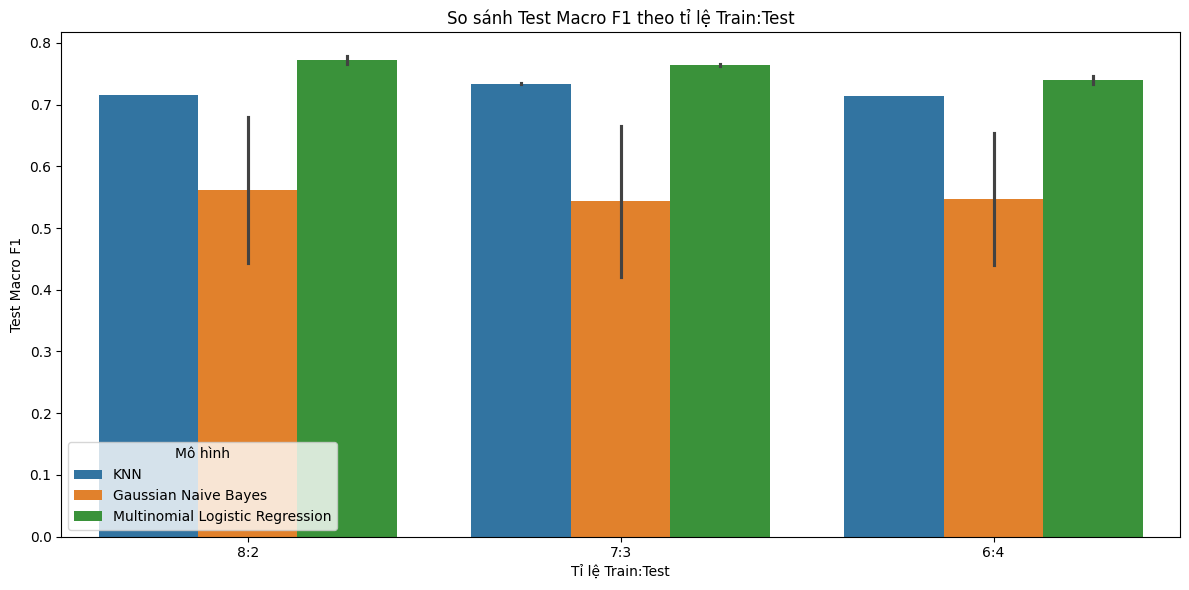

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=classification_results,
    x="Mô hình",
    y="Test Accuracy",
    hue="Dữ liệu"
)
plt.title("So sánh Test Accuracy giữa các mô hình")
plt.xlabel("Mô hình")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
sns.barplot(
    data=classification_results,
    x="Mô hình",
    y="Test Macro F1",
    hue="Dữ liệu"
)
plt.title("So sánh Test Macro F1 giữa các mô hình")
plt.xlabel("Mô hình")
plt.ylabel("Test Macro F1")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
sns.barplot(
    data=classification_results,
    x="Train:Test",
    y="Test Macro F1",
    hue="Mô hình"
)
plt.title("So sánh Test Macro F1 theo tỉ lệ Train:Test")
plt.xlabel("Tỉ lệ Train:Test")
plt.ylabel("Test Macro F1")
plt.tight_layout()
plt.show()